# Understand the chain: subsurface uncertainty to integrated development decisions

### Norne open reservoir data · OPM Flow · NeqSim three-phase transport · facilities · Python ML

**The best reservoir strategy is not necessarily the best production-system strategy.**
This notebook makes that statement testable. We run a full-grid OPM Flow model derived from
published Norne inputs, translate production into a mass-conserving fluid handoff, calculate
well and subsea transport with NeqSim's `TwoFluidPipe`, and solve a host process. Python
machine learning then helps select additional simulations and compare constrained decisions.

The public reservoir geometry, rock, PVT and initial-condition inputs are Norne data.
**The forecast controls, uncertainty distributions, well geometry, tieback, host capacities,
synthetic seismic attributes and economics are teaching assumptions.** This is a hypothetical
development study, not a reconstruction of the installed Norne production system.

[Open in Colab](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/reservoir/integrated_norne_reservoir_to_facilities_ai.ipynb)

[Earlier FMU tutorial](fmu_norne_subsurface_to_facilities_workflow.ipynb) introduces portable
reservoir calculations and ensemble updating. This companion executes OPM Flow directly.

**Read the retained results first.** A full rerun downloads open inputs, builds NeqSim Java,
and runs a bounded OPM ensemble. Use a Linux/Colab runtime with Java, several GB of free RAM,
and sufficient disk space. Failed simulations are failures, never substituted by decline curves.

## Learning route

1. Understand the interfaces and the feedback loops between disciplines.
2. Inspect the open reservoir data and the distinction between measurements and interpretations.
3. Build a simple seismic/log uncertainty demonstration with spatial holdout validation.
4. Run the Norne grid in OPM Flow under explicitly hypothetical forecast controls.
5. Examine well placement and tubing choices, and translate bottom-hole pressure consistently.
6. Transport gas, oil and water with `TwoFluidPipe`, including oil/water holdups and residuals.
7. Check thermal margins, cooldown, and the scope of flow-assurance qualification.
8. Solve separation and gas compression with NeqSim and calculate host headroom.
9. Train, validate and adapt a surrogate using actual simulator responses.
10. Compare reservoir-only, coupled, and capacity-upgrade decisions under uncertainty.
11. Export traceable results and explain what evidence is still needed before design decisions.

The live-demo checkpoints are the subsurface maps, OPM forecasts, pressure/holdup profiles,
host-utilization chart, ML validation plot, and final decision table.

In [1]:
import importlib.metadata
import os
from pathlib import Path
import shutil
import subprocess
import sys

PACKAGES = {
    "numpy": "2.2.6",
    "pandas": "2.2.3",
    "scipy": "1.15.3",
    "scikit-learn": "1.6.1",
    "matplotlib": "3.10.3",
    "neqsim": "3.20.0",
    "opm": "2026.4",
}
missing = []
for name, version in PACKAGES.items():
    try:
        installed = importlib.metadata.version(name)
    except importlib.metadata.PackageNotFoundError:
        installed = None
    if installed != version:
        missing.append(f"{name}=={version}")
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

FLOW = os.environ.get("OPM_FLOW_EXECUTABLE") or shutil.which("flow")
if FLOW is None:
    prefix = [] if os.geteuid() == 0 else ["sudo"]
    commands = [
        ["apt-get", "update", "-qq"],
        ["apt-get", "install", "-y", "-qq", "software-properties-common"],
        ["add-apt-repository", "-y", "ppa:opm/ppa"],
        ["apt-get", "update", "-qq"],
        ["apt-get", "install", "-y", "-qq", "libopm-simulators-bin"],
    ]
    for command in commands:
        result = subprocess.run(prefix + command, capture_output=True, text=True)
        if result.returncode:
            raise RuntimeError(result.stdout[-2000:] + result.stderr[-3000:])
    FLOW = shutil.which("flow")
assert FLOW, "OPM Flow is required; no reduced-model fallback is used."
FLOW_ENV = os.environ.copy()
FLOW_ENV["OMP_NUM_THREADS"] = "2"
print(subprocess.check_output([FLOW, "--version"], env=FLOW_ENV, text=True).strip())
print("Python dependencies:", PACKAGES)


flow 2026.04
Python dependencies: {'numpy': '2.2.6', 'pandas': '2.2.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1', 'matplotlib': '3.10.3', 'neqsim': '3.20.0', 'opm': '2026.4'}


## 1. Reproducible simulator provenance

The Python package supplies the bridge; the Java calculations use a source-built NeqSim JAR.
The default fetches `master`. To reproduce the retained run exactly, set `NEQSIM_SOURCE_REF`
to its recorded commit. A prebuilt runtime is accepted only with its source checkout and
class-location check. Start with a fresh Python kernel when changing Java versions.

In [2]:
import hashlib
import importlib.util
import json
import time
import urllib.parse

import jpype


def command_output(command, cwd=None, timeout=2400):
    result = subprocess.run(
        command,
        cwd=cwd,
        capture_output=True,
        text=True,
        timeout=timeout,
    )
    if result.returncode:
        raise RuntimeError(result.stdout[-3000:] + result.stderr[-3000:])
    return result.stdout.strip()


NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
source_setting = os.environ.get("NEQSIM_SOURCE_ROOT")
jar_setting = os.environ.get("NEQSIM_SOURCE_JAR")
if source_setting and jar_setting:
    neqsim_source = Path(source_setting).resolve()
    neqsim_jar = Path(jar_setting).resolve()
else:
    neqsim_source = Path("neqsim-source").resolve()
    if not neqsim_source.exists():
        command_output(
            ["git", "clone", "https://github.com/equinor/neqsim", str(neqsim_source)]
        )
    command_output(["git", "fetch", "origin", NEQSIM_SOURCE_REF], cwd=neqsim_source)
    command_output(["git", "checkout", "--detach", "FETCH_HEAD"], cwd=neqsim_source)
    command_output(
        [
            "./mvnw",
            "-q",
            "-DskipTests",
            "-Dmaven.javadoc.skip=true",
            "package",
        ],
        cwd=neqsim_source,
    )
    jars = [
        path
        for path in (neqsim_source / "target").glob("neqsim-*.jar")
        if "sources" not in path.name and "javadoc" not in path.name
    ]
    neqsim_jar = max(jars, key=lambda path: path.stat().st_size)

neqsim_commit = command_output(["git", "rev-parse", "HEAD"], cwd=neqsim_source)
neqsim_jar_sha256 = hashlib.sha256(neqsim_jar.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
assert not jpype.isJVMStarted(), "Restart the kernel before changing the Java classpath."
jpype.addClassPath(str(neqsim_jar))
jpype.startJVM("-Xmx1800m")
J = jpype.JClass
Pipe = J("neqsim.process.equipment.pipeline.TwoFluidPipe")
Report = J("neqsim.process.equipment.pipeline.SteadyStateConvergenceReport")
location = str(Report.class_.getProtectionDomain().getCodeSource().getLocation().toURI())
loaded_path = Path(urllib.parse.unquote(urllib.parse.urlparse(location).path)).resolve()
assert loaded_path == neqsim_jar
provenance = {
    "source": "equinor/neqsim",
    "ref": NEQSIM_SOURCE_REF,
    "commit": neqsim_commit,
    "jar_sha256": neqsim_jar_sha256,
    "loaded_class_location": location,
    "flow": command_output([FLOW, "--version"]),
    "python": sys.version.split()[0],
}
print(json.dumps(provenance, indent=2))


{
  "source": "equinor/neqsim",
  "ref": "e4baa50c8fb0815e52c38ddcb93f806e6907ece8",
  "commit": "e4baa50c8fb0815e52c38ddcb93f806e6907ece8",
  "jar_sha256": "d547d584fa23e496943b22359a5e2f6860241887c3b1425e0c95751a23aad311",
  "loaded_class_location": "file:/home/runner/work/NeqSim-Colab/NeqSim-Colab/neqsim-source/target/neqsim-3.20.0.jar",
  "flow": "flow 2026.04",
  "python": "3.12.14"
}


In [3]:
import re
from concurrent.futures import ThreadPoolExecutor
import urllib.request

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter
from scipy.stats import qmc
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from opm.io.ecl import ESmry
from IPython.display import display
from textwrap import fill

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
RNG = np.random.default_rng(7291)
OUT = Path("chain_artifacts").resolve()
OUT.mkdir(exist_ok=True)
plt.rcParams.update(
    {
        "figure.dpi": 125,
        "font.size": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "figure.constrained_layout.use": True,
    }
)
COLORS = ["#176B87", "#E07A3F", "#38846E", "#9166AA", "#BB4455"]
FIGURES = []


def show_figure(figure, name):
    path = OUT / (name + ".png")
    figure.savefig(path, dpi=160, facecolor="white")
    FIGURES.append(path.name)
    plt.show()
    plt.close(figure)


### Coupling means exchanging constraints as well as forecasts

| Interface | Forward variables | Feedback variables | Required checks |
|---|---|---|---|
| Subsurface → reservoir | geometry, porosity, permeability, contacts, PVT | value of information, forecast sensitivity | provenance, units, active cells |
| Reservoir → well | component/black-oil rates, BHP at a stated datum | feasible BHP and rate controls | standard conditions, phase accounting |
| Well → subsea | pressure, temperature, mass/component rates | backpressure, tubing and choke choices | momentum and energy consistency |
| Subsea → host | arrival fluid, pressure, temperature, slug context | receiving pressure, headroom, restart restrictions | phase inventory and convergence |
| Host → decisions | export, duties, utilization | water/gas/power limits and upgrade value | total and component mass closure |
| All modules → ML | qualified inputs and results | requests for new simulator evaluations | held-out validation, uncertainty, budget |

A surrogate proposes a candidate. The numerical simulators accept or reject it. The
orchestrator cannot declare a failed solve feasible, invent a simulator result, or change
engineering acceptance thresholds to make an attractive decision pass.

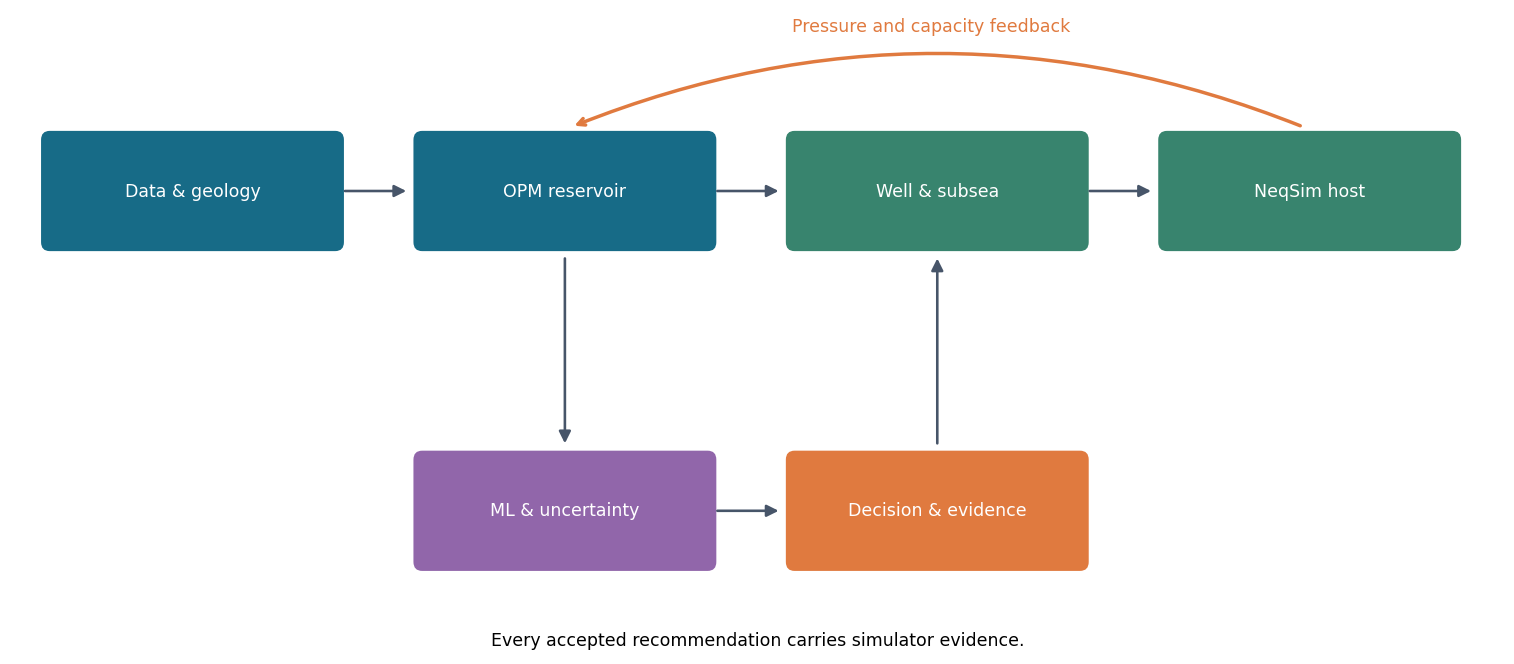

In [4]:
fig, ax = plt.subplots(figsize=(12, 5.2))
ax.set(xlim=(0, 12), ylim=(0, 5))
ax.axis("off")
boxes = [
    (0.3, 3.2, "Data & geology", COLORS[0]),
    (3.3, 3.2, "OPM reservoir", COLORS[0]),
    (6.3, 3.2, "Well & subsea", COLORS[2]),
    (9.3, 3.2, "NeqSim host", COLORS[2]),
    (3.3, 0.7, "ML & uncertainty", COLORS[3]),
    (6.3, 0.7, "Decision & evidence", COLORS[1]),
]
for x, y, label, color in boxes:
    ax.add_patch(
        FancyBboxPatch(
            (x, y), 2.3, 0.8, boxstyle="round,pad=0.07", facecolor=color, edgecolor="none"
        )
    )
    ax.text(x + 1.15, y + 0.4, label, ha="center", va="center", color="white")
for start, end in [
    ((2.65, 3.6), (3.2, 3.6)),
    ((5.65, 3.6), (6.2, 3.6)),
    ((8.65, 3.6), (9.2, 3.6)),
    ((5.65, 1.1), (6.2, 1.1)),
    ((4.45, 3.1), (4.45, 1.6)),
    ((7.45, 1.6), (7.45, 3.1)),
]:
    ax.add_patch(
        FancyArrowPatch(
            start, end, arrowstyle="-|>", mutation_scale=14, color="#475569", linewidth=1.5
        )
    )
ax.annotate(
    "",
    xy=(4.5, 4.1),
    xytext=(10.4, 4.1),
    arrowprops={
        "arrowstyle": "->",
        "connectionstyle": "arc3,rad=0.2",
        "color": COLORS[1],
        "linewidth": 2,
    },
)
ax.text(7.4, 4.85, "Pressure and capacity feedback", ha="center", color=COLORS[1])
ax.text(6, 0.05, "Every accepted recommendation carries simulator evidence.", ha="center")
show_figure(fig, "01_coupled_chain")


## 2. Norne open inputs: what is observed and what is interpreted?

The model is retrieved from the [OPM open-data repository](https://github.com/OPM/opm-data/tree/eaa2261683a97027e057c2bc49612ad1c86390b3/norne)
at an immutable commit. Its embedded [ODbL](https://opendatacommons.org/licenses/odbl/1-0/)
and [DbCL](https://opendatacommons.org/licenses/dbcl/1-0/) notices remain with the files.
Retain those notices when sharing a derived database. The notebook links to source files;
it does not claim ownership of the source dataset.

The grid contains interpreted properties, not raw seismic traces. We use its porosity,
permeability, net-to-gross, active cells, initial water saturation, PVT and completions.
Raw SEG-Y, well logs, checkshots, structural interpretation uncertainty, and alternative
history matches would be needed for a field-calibrated subsurface posterior.

The synthetic measurement experiment below explains the data-science interface without
misrepresenting a generated seismic attribute as an observed Norne measurement.

In [5]:
DATA_COMMIT = "eaa2261683a97027e057c2bc49612ad1c86390b3"
DATA_ROOT = Path(os.environ.get("NORNE_DATA_ROOT", "norne-open-data")).resolve()
DATA_ROOT.mkdir(exist_ok=True)
manifest_url = (
    "https://api.github.com/repos/OPM/opm-data/git/trees/" + DATA_COMMIT + "?recursive=1"
)
with urllib.request.urlopen(manifest_url, timeout=90) as response:
    tree = json.load(response)["tree"]
source_files = [
    item
    for item in tree
    if item["path"].startswith("norne/")
    and item["type"] == "blob"
    and not item["path"].endswith((".pdf", ".sh"))
]


def verified_download(item):
    relative = item["path"][len("norne/") :]
    path = DATA_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    if not path.exists():
        url = f"https://raw.githubusercontent.com/OPM/opm-data/{DATA_COMMIT}/{item['path']}"
        with urllib.request.urlopen(url, timeout=180) as response:
            path.write_bytes(response.read())
    data = path.read_bytes()
    blob = hashlib.sha1(f"blob {len(data)}\0".encode() + data).hexdigest()
    assert blob == item["sha"], f"Source integrity mismatch: {relative}"
    return {"path": relative, "bytes": len(data), "sha256": hashlib.sha256(data).hexdigest()}


with ThreadPoolExecutor(max_workers=6) as executor:
    manifest = list(executor.map(verified_download, source_files))
(OUT / "source_manifest.json").write_text(json.dumps(manifest, indent=2))
display(pd.DataFrame(manifest)[["path", "bytes"]].head(12))
print(f"Verified {len(manifest)} files at immutable commit {DATA_COMMIT}.")


,path,bytes
0,INCLUDE/BC0407_HIST01122006.SCH,462215
1,INCLUDE/FAULT/FAULTMULT_AUG-2006.INC,1413
2,INCLUDE/FAULT/FAULT_JUN_05.INC,61038
3,INCLUDE/GRID/ACTNUM_0704.prop,229483
4,INCLUDE/GRID/IRAP_1005.GRDECL,11318913
5,INCLUDE/PETRO/E3.prop,1280
6,INCLUDE/PETRO/EQLNUM_0704.prop,1045067
7,INCLUDE/PETRO/EXTRA_REG.inc,1891
8,INCLUDE/PETRO/FIPNUM_0704.prop,1045067
9,INCLUDE/PETRO/FLUXNUM_0704.prop,1045068


Verified 64 files at immutable commit eaa2261683a97027e057c2bc49612ad1c86390b3.


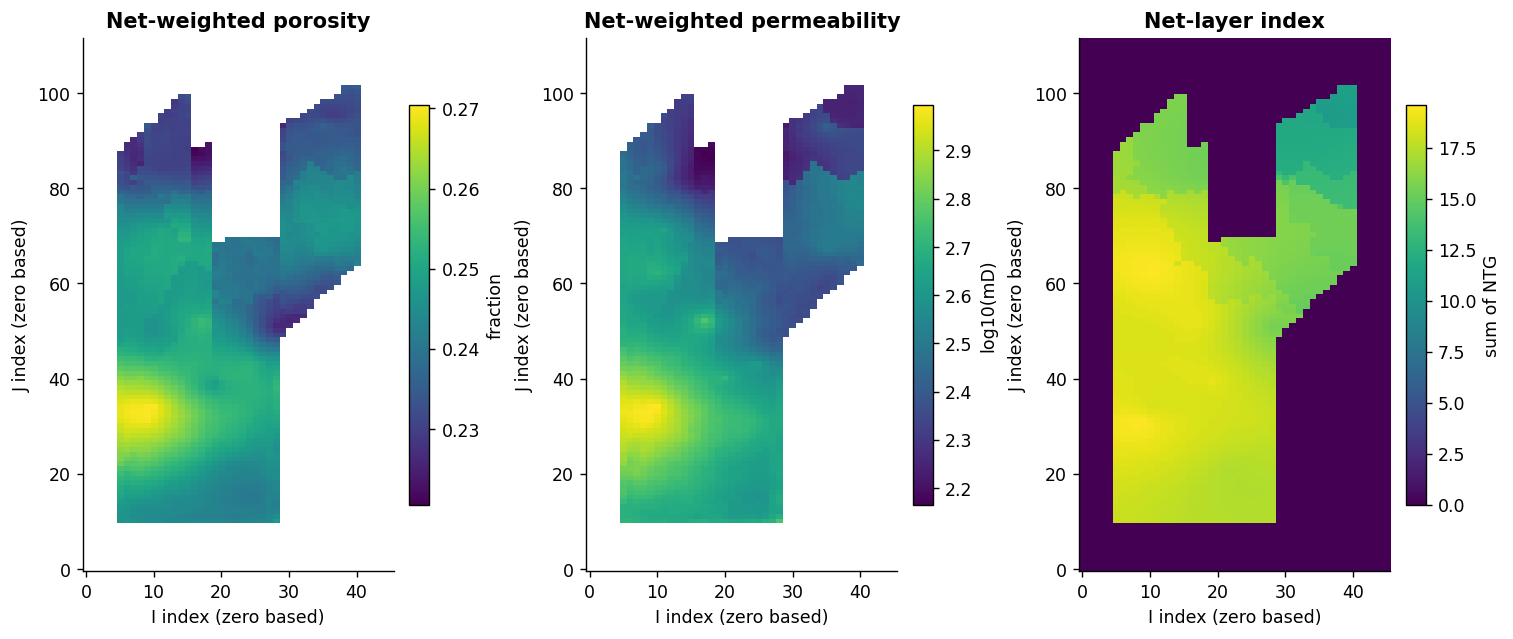

In [6]:
def read_array(relative_path, keyword):
    text = (DATA_ROOT / relative_path).read_text()
    text = "\n".join(line.split("--")[0] for line in text.splitlines())
    values_text = text.split(keyword, 1)[1].split("/", 1)[0]
    values = []
    for token in values_text.split():
        if "*" in token:
            count, value = token.split("*")
            if not value:
                raise ValueError("Implicit defaults require the OPM parser.")
            values.extend([float(value)] * int(count))
        else:
            values.append(float(token))
    array = np.asarray(values)
    assert array.size == 46 * 112 * 22
    return array.reshape((46, 112, 22), order="F")


poro = read_array("INCLUDE/PETRO/PORO_0704.prop", "PORO")
perm = read_array("INCLUDE/PETRO/PERM_0704.prop", "PERMX")
ntg = read_array("INCLUDE/PETRO/NTG_0704.prop", "NTG")
active = read_array("INCLUDE/GRID/ACTNUM_0704.prop", "ACTNUM") > 0.5
sw = read_array("INCLUDE/PETRO/SWINITIAL.INC", "SWATINIT")
assert active.sum() == 44927
assert np.all((poro[active] > 0) & (poro[active] < 1))
assert np.all(perm[active] >= 0)
weights = np.where(active, ntg, 0)
column_weight = weights.sum(axis=2)
phi_map = np.divide(
    (poro * weights).sum(axis=2),
    column_weight,
    out=np.full(column_weight.shape, np.nan),
    where=column_weight > 0,
)
k_map = np.divide(
    (perm * weights).sum(axis=2),
    column_weight,
    out=np.full(column_weight.shape, np.nan),
    where=column_weight > 0,
)
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
for ax, values, title, unit in zip(
    axes,
    [phi_map, np.log10(np.maximum(k_map, 0.01)), column_weight],
    ["Net-weighted porosity", "Net-weighted permeability", "Net-layer index"],
    ["fraction", "log10(mD)", "sum of NTG"],
):
    image = ax.imshow(values.T, origin="lower", cmap="viridis", aspect="auto")
    ax.set(xlabel="I index (zero based)", ylabel="J index (zero based)", title=title)
    fig.colorbar(image, ax=ax, label=unit, shrink=0.75)
show_figure(fig, "02_norne_property_maps")


## 3. Seismic/log uncertainty and Python learning

A deliberately simplified rock-physics experiment creates a synthetic acoustic-impedance
attribute from the interpreted porosity. The forward relation includes correlated spatial
noise. A random forest learns porosity from this attribute and depth index using a spatial
training block; the remaining block is held out. Random row splitting would place nearby,
correlated cells in both training and validation sets and overstate generalization.

This demonstrates how uncertainty enters the chain. It does not provide a new Norne seismic
inversion. The later OPM ensemble uses transparent engineering priors; we do not pretend
that this two-feature model determines permeability or a calibrated reservoir posterior.

$$Z=\rho V_p$$

Here $Z$ is acoustic impedance in kg/(m² s), $\rho$ is bulk density in kg/m³, and $V_p$ is
compressional velocity in m/s. The synthetic formula and its coefficients are assumptions.

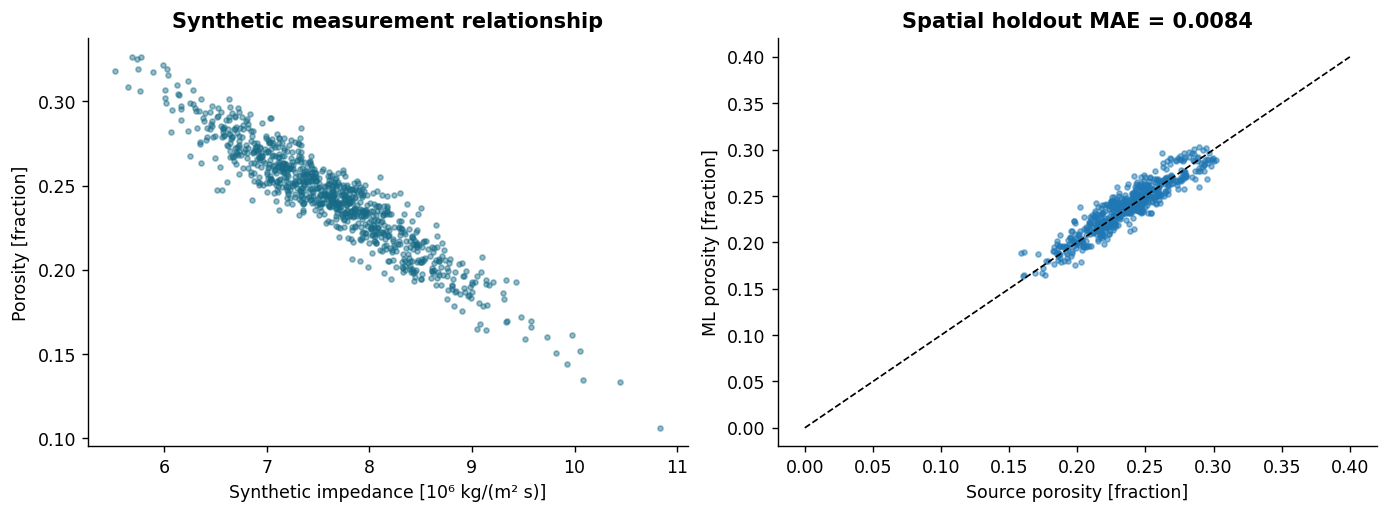

,uncertainty,range,status
0,Porosity multiplier,0.92–1.08,Teaching prior
1,Permeability multiplier,0.65–1.45,Teaching prior
2,BHP decision,205–255 bara,Hypothetical control
3,Water-injection decision,2500–6500 Sm³/day,Hypothetical control


In [7]:
indices = np.argwhere(active)
phi_values = poro[active]
correlated_noise = gaussian_filter(RNG.normal(size=poro.shape), sigma=2.0)
correlated_noise /= correlated_noise.std()
rho_bulk = 2650 * (1 - phi_values) + 1033 * phi_values
vp = 5300 - 8000 * phi_values + 120 * correlated_noise[active]
impedance = rho_bulk * vp
features = np.column_stack([impedance / 1e6, indices[:, 2]])
spatial_train = indices[:, 1] < 65
rock_model = RandomForestRegressor(n_estimators=120, min_samples_leaf=20, random_state=7291)
rock_model.fit(features[spatial_train], phi_values[spatial_train])
phi_prediction = rock_model.predict(features[~spatial_train])
rock_mae = mean_absolute_error(phi_values[~spatial_train], phi_prediction)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(features[::50, 0], phi_values[::50], s=8, alpha=0.45, color=COLORS[0])
axes[0].set(
    xlabel="Synthetic impedance [10⁶ kg/(m² s)]",
    ylabel="Porosity [fraction]",
    title="Synthetic measurement relationship",
)
axes[1].scatter(phi_values[~spatial_train][::25], phi_prediction[::25], s=8, alpha=0.5)
axes[1].plot([0, 0.4], [0, 0.4], "k--", linewidth=1)
axes[1].set(
    xlabel="Source porosity [fraction]",
    ylabel="ML porosity [fraction]",
    title=f"Spatial holdout MAE = {rock_mae:.4f}",
)
show_figure(fig, "03_spatial_ml_validation")
display(
    pd.DataFrame(
        {
            "uncertainty": [
                "Porosity multiplier",
                "Permeability multiplier",
                "BHP decision",
                "Water-injection decision",
            ],
            "range": ["0.92–1.08", "0.65–1.45", "205–255 bara", "2500–6500 Sm³/day"],
            "status": [
                "Teaching prior",
                "Teaching prior",
                "Hypothetical control",
                "Hypothetical control",
            ],
        }
    )
)


## 4. An actual OPM Flow reservoir forecast

We retain the full 46 × 112 × 22 Norne corner-point geometry, faults, rock, black-oil PVT,
and initialization. We replace the historical schedule with **hypothetical** BHP-controlled
production at two existing completion sets and water injection at a third. The explicit
BHP reference depth is 2700 m. This is a prospective sensitivity experiment from the source
initial state, not an observed historical forecast or a reserves estimate.

Uncertainty multiplies porosity and all permeability directions before OPM initialization.
The original relative-permeability, fault and PVT data remain part of the model. A one-year
forecast measures short-horizon recovery; extrapolating it to ultimate recoverable volumes
would be unjustified.

$$N_p(t)=\int_0^t q_o(\tau)\,d\tau$$

$N_p$ is cumulative surface oil volume in Sm³, $q_o$ is oil rate in Sm³/day, and $t$ is days.
OPM reports the cumulative quantity directly; we do not sum rate samples as if they were volumes.

In [8]:
RUN_ROOT = OUT / "opm_runs"
RUN_ROOT.mkdir(exist_ok=True)
MODEL_VERSION = "integrated-norne-chain-1"


def make_deck(bhp=230.0, injection=4500.0, k_mult=1.0, pv_mult=1.0, days=360.0, steps=12):
    original = (DATA_ROOT / "NORNE_ATW2013.DATA").read_text()
    prefix = re.split(r"(?m)^SUMMARY\s*$", original)[0]
    prefix = prefix.replace("'./INCLUDE/", "'" + str(DATA_ROOT / "INCLUDE") + "/")
    multiplier = (
        "\nMULTIPLY\n"
        f" 'PORO' {pv_mult:.9g} /\n"
        f" 'PERMX' {k_mult:.9g} /\n"
        f" 'PERMY' {k_mult:.9g} /\n"
        f" 'PERMZ' {k_mult:.9g} /\n/\n"
    )
    prefix = re.sub(r"(?m)^EDIT\s*$", multiplier + "\nEDIT", prefix)
    schedule = (DATA_ROOT / "INCLUDE/BC0407_HIST01122006.SCH").read_text()
    wells = schedule[schedule.index("WELSPECS") : schedule.index("WCONHIST")]
    wells = re.sub(r"(\s\d+\s+\d+)\s+1\*\s+'OIL'", r"\1 2700 'OIL'", wells)
    summary = "\nSUMMARY\nFOPR\nFWPR\nFGPR\nFOPT\nFWPT\nFGPT\nFPR\nFOIP\n"
    for key in ["WOPR", "WWPR", "WGPR", "WBHP"]:
        summary += key + "\n/\n"
    controls = (
        "\nWCONPROD\n"
        f" 'B-2H' 'OPEN' 'BHP' 5* {bhp:.9g} /\n"
        f" 'D-1H' 'OPEN' 'BHP' 5* {bhp:.9g} /\n/\n"
        "\nWCONINJE\n"
        f" 'C-4H' 'WATER' 'OPEN' 'RATE' {injection:.9g} 1* 400 /\n/\n"
        "\nRPTRST\n BASIC=2 /\n"
        f"\nTSTEP\n {steps}*{days / steps:.9g} /\nEND\n"
    )
    return prefix + summary + "\nSCHEDULE\n" + wells + controls


def run_reservoir(parameters, use_cache=True):
    config = {**parameters, "model": MODEL_VERSION, "data_commit": DATA_COMMIT}
    identifier = hashlib.sha256(json.dumps(config, sort_keys=True).encode()).hexdigest()[:16]
    folder = RUN_ROOT / identifier
    folder.mkdir(exist_ok=True)
    deck = make_deck(**parameters)
    deck_hash = hashlib.sha256(deck.encode()).hexdigest()
    evidence_path = folder / "run.json"
    cached = False
    if use_cache and evidence_path.exists():
        evidence = json.loads(evidence_path.read_text())
        cached = evidence.get("deck_sha256") == deck_hash and evidence.get("exit_code") == 0
        for name, digest in evidence.get("outputs", {}).items():
            path = folder / name
            cached &= path.exists()
            if path.exists():
                cached &= hashlib.sha256(path.read_bytes()).hexdigest() == digest
    if not cached:
        (folder / "CASE.DATA").write_text(deck)
        started = time.perf_counter()
        with (folder / "stdout.log").open("w") as log:
            completed = subprocess.run(
                [
                    FLOW,
                    str(folder / "CASE.DATA"),
                    "--output-dir=" + str(folder),
                    "--threads-per-process=2",
                ],
                env=FLOW_ENV,
                stdout=log,
                stderr=subprocess.STDOUT,
                timeout=1200,
            )
        if completed.returncode:
            raise RuntimeError((folder / "stdout.log").read_text()[-7000:])
        outputs = {}
        for suffix in ["SMSPEC", "UNSMRY"]:
            path = folder / ("CASE." + suffix)
            assert path.exists(), f"Missing OPM result: {suffix}"
            outputs[path.name] = hashlib.sha256(path.read_bytes()).hexdigest()
        evidence = {
            "config": config,
            "id": identifier,
            "deck_sha256": deck_hash,
            "outputs": outputs,
            "elapsed_s": time.perf_counter() - started,
            "exit_code": 0,
            "simulator": provenance["flow"],
        }
        evidence_path.write_text(json.dumps(evidence, indent=2))
    summary = ESmry(str(folder / "CASE.SMSPEC"))
    result = {"day": np.asarray(summary["TIME"], dtype=float)}
    for key in ["FOPR", "FWPR", "FGPR", "FOPT", "FWPT", "FGPT", "FPR", "FOIP"]:
        result[key] = np.asarray(summary[key], dtype=float)
    for well in ["B-2H", "D-1H"]:
        for key in ["WOPR", "WWPR", "WGPR", "WBHP"]:
            result[key + ":" + well] = np.asarray(summary[key + ":" + well], dtype=float)
    frame = pd.DataFrame(result)
    assert np.all(np.isfinite(frame.to_numpy()))
    assert abs(frame.day.iloc[-1] - parameters.get("days", 360.0)) < 1e-4
    assert np.all(frame[["FOPR", "FWPR", "FGPR"]] >= -1e-8)
    assert np.all(np.diff(frame.FOPT) >= -1e-4)
    assert np.allclose(frame["WOPR:B-2H"] + frame["WOPR:D-1H"], frame.FOPR, rtol=1e-5)
    evidence = {**evidence, "folder": str(folder), "cache_reused": bool(cached)}
    return frame, evidence


base_parameters = {"bhp": 230.0, "injection": 4500.0, "k_mult": 1.0, "pv_mult": 1.0}
base_forecast, base_evidence = run_reservoir(base_parameters)
display(base_forecast[["day", "FOPR", "FWPR", "FGPR", "FOPT", "FPR"]].round(3))
print(json.dumps(base_evidence, indent=2))


,day,FOPR,FWPR,FGPR,FOPT,FPR
0,1.0,14627.095,9.326,1584910.625,14627.095,271.544
1,4.0,13427.215,8.638,1454561.875,54908.738,270.973
2,11.8,12400.319,8.081,1342735.625,151631.234,269.891
3,30.0,11251.834,7.484,1217558.125,356414.625,267.876
4,60.0,9980.074,6.855,1078992.875,655816.875,265.126
5,90.0,8968.756,6.374,968420.500,924879.562,262.801
6,120.0,8052.396,5.984,866335.312,1166451.375,260.842
7,150.0,7238.960,5.671,775675.375,1383620.250,259.212
8,180.0,6568.959,5.402,701326.938,1580689.000,257.878
9,210.0,6018.494,5.163,640921.188,1761243.875,256.787


{
  "config": {
    "bhp": 230.0,
    "injection": 4500.0,
    "k_mult": 1.0,
    "pv_mult": 1.0,
    "model": "integrated-norne-chain-1",
    "data_commit": "eaa2261683a97027e057c2bc49612ad1c86390b3"
  },
  "id": "05cd6ed3882dec37",
  "deck_sha256": "0484f892646cba711e7354d50b2174eee3da2a0f4cbc1eb94c80f41be18276ec",
  "outputs": {
    "CASE.SMSPEC": "a1013af252819928423d1238d434d7caa5c090a5f815591c08b564014a3ef104",
    "CASE.UNSMRY": "15ebdb3292199453c636c15ec3023d8a7ae2a0a8f4b6cbd1541f8f33afa1bf77"
  },
  "elapsed_s": 8.681442533999984,
  "exit_code": 0,
  "simulator": "flow 2026.04",
  "folder": "/home/runner/work/NeqSim-Colab/NeqSim-Colab/chain_artifacts/opm_runs/05cd6ed3882dec37",
  "cache_reused": true
}


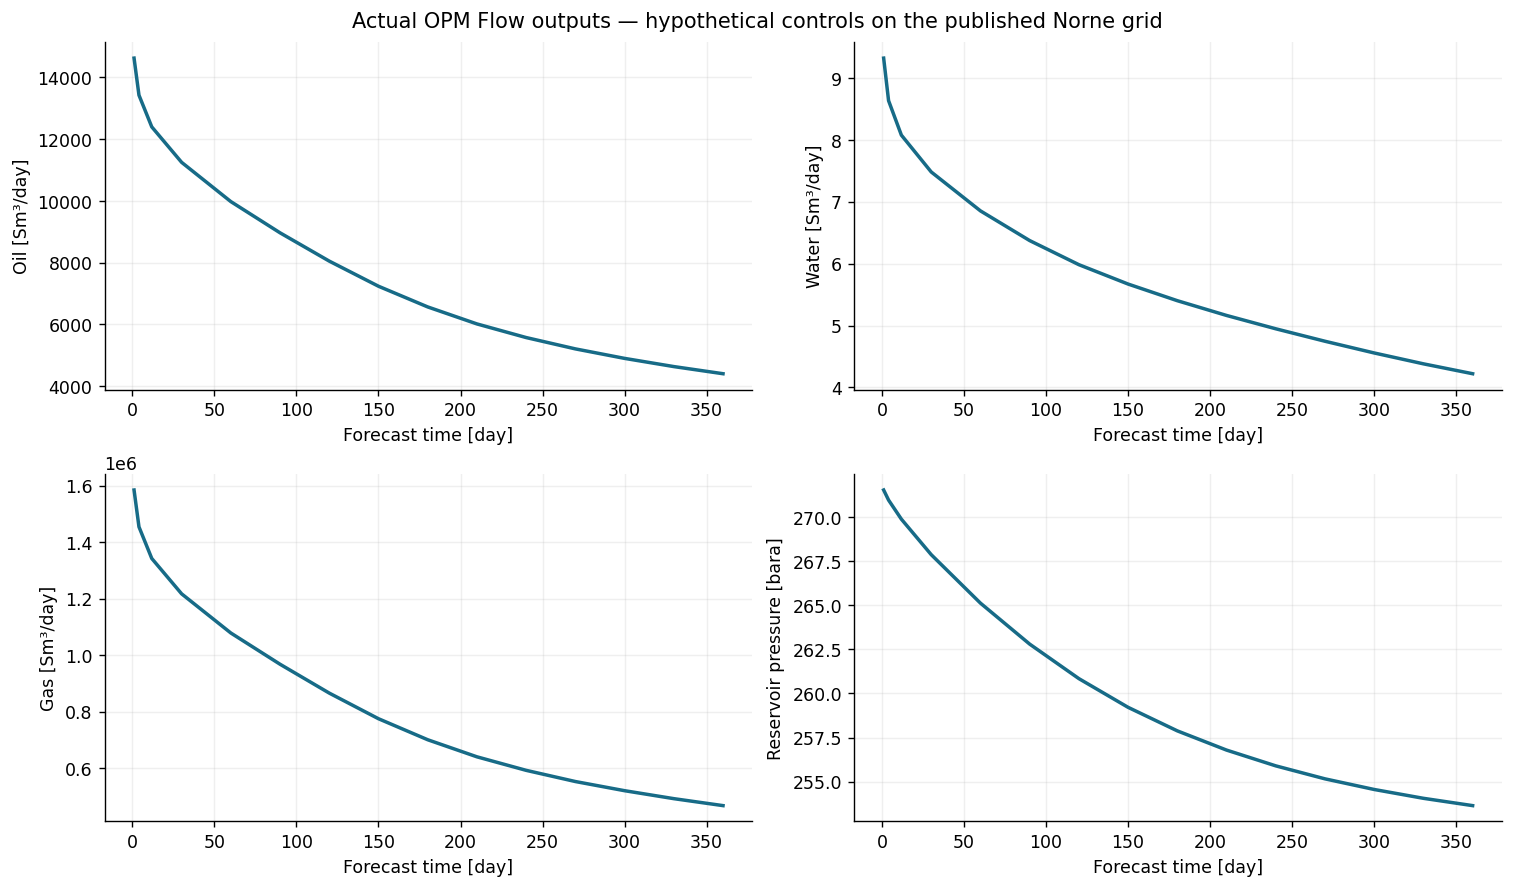

One-year cumulative oil [million Sm³]: 2.50322875
These short-horizon volumes are not reserves or ultimate recovery.


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, key, label in zip(
    axes.flat,
    ["FOPR", "FWPR", "FGPR", "FPR"],
    ["Oil [Sm³/day]", "Water [Sm³/day]", "Gas [Sm³/day]", "Reservoir pressure [bara]"],
):
    ax.plot(base_forecast.day, base_forecast[key], color=COLORS[0], linewidth=2)
    ax.set(xlabel="Forecast time [day]", ylabel=label)
    ax.grid(alpha=0.2)
fig.suptitle("Actual OPM Flow outputs — hypothetical controls on the published Norne grid")
show_figure(fig, "04_opm_forecast")
print("One-year cumulative oil [million Sm³]:", base_forecast.FOPT.iloc[-1] / 1e6)
print("These short-horizon volumes are not reserves or ultimate recovery.")


## 5. Well design is part of the system decision

Well placement begins with connected pore volume, transmissibility, fluid contacts and
sweep. High local permeability alone does not establish a good producer. The map below
screens candidates with a net-layer/porosity/permeability index; it is not a drilling plan.
The numerical forecast uses the published completion cells of two wells.

Tubing size, trajectory, completion productivity, sand control, injection support, and
allowable drawdown must then be considered together. We compare three internal tubing
diameters in the hydraulic model. The assumed path rises from the 2700 m BHP datum to a
320 m seabed, followed by a 6 km tieback and a 320 m riser. These dimensions are hypothetical.

$$p_{bh}=p_{host}+\Delta p_{well}+\Delta p_{flowline+riser}+\Delta p_{choke}$$

Here $p_{host}$ is the receiving pressure after the choke; the calculated pre-choke
arrival pressure is $p_{arrival}=p_{host}+\Delta p_{choke}$. All pressures and pressure
differences are in bar, with absolute pressure used for $p$. The pressure losses include hydrostatic and frictional effects
computed by the flow model. We never subtract a fixed guessed wellhead-pressure offset
from reservoir pressure. A negative available choke drop means the proposed reservoir
rate/BHP pair cannot deliver to that receiving pressure with this assumed geometry.

Mechanical casing design, burst/collapse, fatigue, sand production, trajectory feasibility,
barrier design and well integrity require further data and are outside this hydraulic screen.

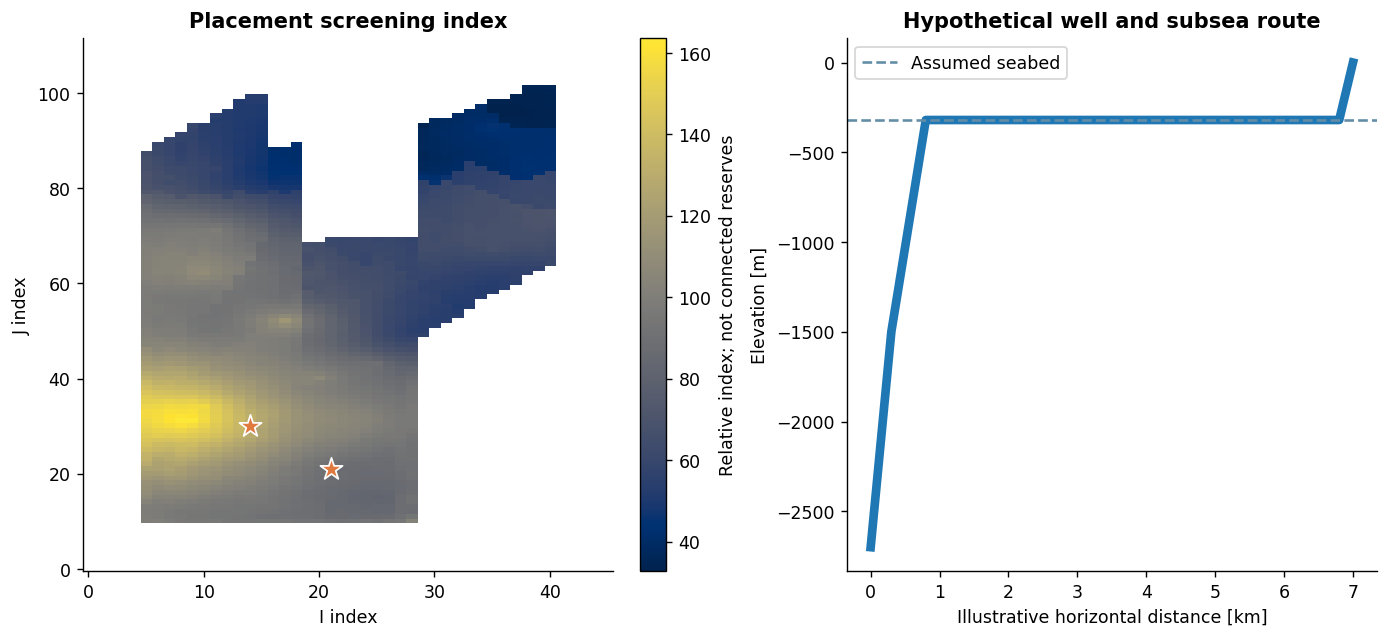

In [10]:
score = phi_map * column_weight * np.sqrt(np.maximum(k_map, 0))
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
image = axes[0].imshow(score.T, origin="lower", aspect="auto", cmap="cividis")
axes[0].scatter([14, 21], [30, 21], marker="*", s=180, color=COLORS[1], edgecolor="white")
axes[0].set(title="Placement screening index", xlabel="I index", ylabel="J index")
fig.colorbar(image, ax=axes[0], label="Relative index; not connected reserves")
axes[1].plot([0, 0.3, 0.8, 6.8, 7.0], [-2700, -1500, -320, -320, 0], linewidth=5)
axes[1].axhline(-320, color="#638DA7", linestyle="--", label="Assumed seabed")
axes[1].set(
    xlabel="Illustrative horizontal distance [km]",
    ylabel="Elevation [m]",
    title="Hypothetical well and subsea route",
)
axes[1].legend()
show_figure(fig, "05_well_and_route")


## 6. A conservative black-oil → compositional handoff

A black-oil model does not uniquely identify molecular composition. Its surface gas already
includes gas liberated from produced oil. Adding an additional solution-GOR stream would
double count that gas.

We convert the three reported standard volumes to masses using the source PVT region-1
surface densities (859.5 kg/m³ oil, 1033 kg/m³ water, 0.854 kg/m³ gas). A declared surrogate
composition then represents those masses: a methane/ethane/propane/nitrogen/CO₂ gas, a heavy
TBP pseudo-component for stock oil, and water. The oil molecular weight is assumed.

$$\dot m_i=\rho_{i,std}\,q_{i,std}/86400$$

$i$ labels oil, gas or water; $\dot m_i$ is kg/s, $\rho_{i,std}$ is kg/Sm³, and
$q_{i,std}$ is Sm³/day. The factor 86400 converts days to seconds.

Mass is preserved at the interface; **phase volumes, gas solubility and calorific value are
not guaranteed to reproduce the Norne black-oil tables**. The water density includes brine
effects in the black-oil mass conversion, while the downstream thermodynamics use fresh
water; salinity is not modeled. Production work needs fluid characterization and a PVT match.
These approximation errors are separate from the reservoir ensemble spread.

In [11]:
System = J("neqsim.thermo.system.SystemSrkEos")
Stream = J("neqsim.process.equipment.stream.Stream")
Thermo = J("neqsim.thermodynamicoperations.ThermodynamicOperations")
ProcessSystem = J("neqsim.process.processmodel.ProcessSystem")
Valve = J("neqsim.process.equipment.valve.ThrottlingValve")
Cooler = J("neqsim.process.equipment.heatexchanger.Cooler")
Separator = J("neqsim.process.equipment.separator.ThreePhaseSeparator")
Compressor = J("neqsim.process.equipment.compressor.Compressor")
GAS_Z = {"methane": 0.86, "ethane": 0.07, "propane": 0.035, "nitrogen": 0.015, "CO2": 0.02}
MOLAR_MASS = {
    "methane": 0.016043,
    "ethane": 0.030070,
    "propane": 0.044097,
    "nitrogen": 0.0280134,
    "CO2": 0.04401,
}
GAS_MW = sum(GAS_Z[name] * MOLAR_MASS[name] for name in GAS_Z)


def fluid_handoff(oil_sm3_day, gas_sm3_day, water_sm3_day, pressure_bara, temperature_c=90.0):
    masses = (
        np.array([oil_sm3_day * 859.5, gas_sm3_day * 0.854, water_sm3_day * 1033.0]) / 86400
    )
    assert np.all(masses >= 0) and masses.sum() > 0
    fluid = System(temperature_c + 273.15, float(pressure_bara))
    for component, fraction in GAS_Z.items():
        fluid.addComponent(component, float(masses[1] / GAS_MW * fraction))
    fluid.addTBPfraction("stock_oil", float(masses[0] / 0.200), 0.200, 0.8595)
    fluid.addComponent("water", float(masses[2] / 0.01801528))
    fluid.setMixingRule(2)
    fluid.setMultiPhaseCheck(True)
    inlet = Stream("reservoir handoff", fluid)
    # Normalize to exact source mass; tabulated component molar masses differ slightly.
    inlet.setFlowRate(float(masses.sum()), "kg/sec")
    inlet.run()
    assert abs(inlet.getFlowRate("kg/sec") / masses.sum() - 1) < 1e-9
    return inlet, masses


sample = base_forecast.iloc[-1]
feed, stock_masses = fluid_handoff(sample.FOPR, sample.FGPR, sample.FWPR, 230)
phase_rows = []
for index in range(feed.getFluid().getNumberOfPhases()):
    phase = feed.getFluid().getPhase(index)
    phase_rows.append(
        {"phase": str(phase.getPhaseTypeName()), "density_kg_m3": phase.getDensity("kg/m3")}
    )
display(pd.DataFrame(phase_rows))
print("Black-oil source mass [kg/s] — oil, gas, water:", stock_masses)
print("NeqSim inlet total mass [kg/s]:", feed.getFlowRate("kg/sec"))


,phase,density_kg_m3
0,oil,714.854777


Black-oil source mass [kg/s] — oil, gas, water: [43.82758698  4.62836988  0.05045406]
NeqSim inlet total mass [kg/s]: 48.506410921440796


## 7. NeqSim two-fluid calculations with gas, oil and water

`TwoFluidPipe` carries gas and liquid momentum with explicit oil/water phase information
and optional oil/water slip. A three-phase thermodynamic inlet is not by itself proof of a
qualified three-phase hydraulic solve. We inspect oil and water holdups, phase mass-flux
closure, phase-volume closure, and **all six steady convergence residuals**.

The well and subsea models are composable process objects. After each pipe run, we explicitly
refresh the outlet TP equilibrium and physical properties before the next model consumes it.
This guards against stale phase/derivative state after outlet flow normalization; a plausible
heat capacity is an additional acceptance check, not a replacement for convergence. The
outlet-refresh audit retains before/after values so this interface correction is visible.
The reproducible native issue is tracked in [NeqSim #3685](https://github.com/equinor/neqsim/issues/3685). We pass each actual outlet
stream into the next unit. The well is treated as adiabatic for this initial screen; the
flowline exchanges heat with 4 °C seawater. Inclination, slip closures and sparse axial
resolution remain model-form/numerical uncertainties.

A nonconverged solve, pressure-floor hit or failed conservation check is rejected.
[NeqSim #3686](https://github.com/equinor/neqsim/issues/3686) tracks a high-rate case
where native steady convergence coexists with a phase mass-flux deficit. The notebook
retains the rejected input and diagnostic; it does not relax the acceptance tolerance. The model is not used here to claim
validated severe-slugging amplitudes, erosion life, or transient operability qualification.

In [12]:
OUTLET_REFRESH_AUDIT = []


def pipe_run(inlet, name, length, diameter, rise, sections=20, heat_transfer=0.0):
    pipe = Pipe(name, inlet)
    pipe.setLength(float(length))
    pipe.setDiameter(float(diameter))
    pipe.setRoughness(4.5e-5)
    pipe.setNumberOfSections(int(sections))
    pipe.setElevationProfile(np.linspace(0, rise, sections).tolist())
    pipe.setEnableWaterOilSlip(True)
    pipe.setSteadyStateMaxIterations(250)
    pipe.setSteadyStateMaxWallClockTime(90.0)
    if heat_transfer > 0:
        pipe.setSurfaceTemperature(4.0, "C")
        pipe.setHeatTransferCoefficient(float(heat_transfer))
    pipe.run()
    outlet_fluid = pipe.getOutletStream().getFluid()
    before_cp = float(outlet_fluid.getCp("J/kgK"))
    before_phases = int(outlet_fluid.getNumberOfPhases())
    Thermo(outlet_fluid).TPflash()
    outlet_fluid.init(3)
    outlet_fluid.initPhysicalProperties()
    heat_capacity = outlet_fluid.getCp("J/kgK")
    OUTLET_REFRESH_AUDIT.append(
        {
            "segment": name,
            "cp_before_J_kgK": before_cp,
            "cp_after_J_kgK": float(heat_capacity),
            "phases_before": before_phases,
            "phases_after": int(outlet_fluid.getNumberOfPhases()),
        }
    )
    if not 100 < heat_capacity < 20000:
        raise RuntimeError(f"{name}: invalid outlet heat capacity {heat_capacity}")
    report = pipe.getSteadyStateConvergenceReport()
    residuals = {
        "pressure_momentum": report.getPressureMomentumResidual(),
        "pressure_update": report.getPressureUpdateResidual(),
        "liquid_holdup": report.getLiquidHoldupResidual(),
        "liquid_split": report.getLiquidSplitResidual(),
        "thermodynamic": report.getThermodynamicResidual(),
        "pressure_drop": report.getPressureDropResidual(),
    }
    if not report.isConverged():
        raise RuntimeError(f"{name}: {report.getTerminationReason()}, {residuals}")
    if max(residuals.values()) > report.getTolerance():
        raise RuntimeError(f"{name}: residual tolerance exceeded: {residuals}")
    profiles = pd.DataFrame(
        {
            "distance_m": np.asarray(pipe.getPositionProfile()),
            "pressure_bara": np.asarray(pipe.getPressureProfile()) / 1e5,
            "temperature_c": np.asarray(pipe.getTemperatureProfile("C")),
            "oil_holdup": np.asarray(pipe.getOilHoldupProfile()),
            "water_holdup": np.asarray(pipe.getWaterHoldupProfile()),
            "liquid_holdup": np.asarray(pipe.getLiquidHoldupProfile()),
            "gas_mass_kg_s": np.asarray(pipe.getGasMassFlowProfile()),
            "oil_mass_kg_s": np.asarray(pipe.getOilMassFlowProfile()),
            "water_mass_kg_s": np.asarray(pipe.getWaterMassFlowProfile()),
        }
    )
    if not np.allclose(
        profiles.oil_holdup + profiles.water_holdup, profiles.liquid_holdup, atol=1e-9
    ):
        raise RuntimeError(f"{name}: phase holdup closure failed")
    phase_sum = profiles[["gas_mass_kg_s", "oil_mass_kg_s", "water_mass_kg_s"]].sum(axis=1)
    expected_mass = float(inlet.getFlowRate("kg/sec"))
    if not np.allclose(phase_sum, expected_mass, rtol=1e-5, atol=1e-7):
        raise RuntimeError(
            f"{name}: phase mass closure failed; expected={expected_mass:.12g} kg/s, "
            f"profile=[{phase_sum.min():.12g}, {phase_sum.max():.12g}] kg/s"
        )
    if not np.all(profiles.pressure_bara > 1.0):
        raise RuntimeError(f"{name}: pressure floor reached")
    if not np.all((profiles.liquid_holdup >= 0) & (profiles.liquid_holdup <= 1)):
        raise RuntimeError(f"{name}: nonphysical liquid holdup")
    return pipe, profiles, residuals


def transport(oil, gas, water, bhp, tubing=0.23, line_diameter=0.35, sections=20):
    inlet, masses = fluid_handoff(oil, gas, water, bhp)
    well, well_profile, well_residuals = pipe_run(
        inlet,
        "well",
        3100,
        tubing,
        2380,
        sections=sections,
    )
    line, line_profile, line_residuals = pipe_run(
        well.getOutletStream(),
        "flowline and riser",
        6320,
        line_diameter,
        320,
        sections=sections,
        heat_transfer=2.0,
    )
    return {
        "inlet": inlet,
        "well": well,
        "line": line,
        "arrival": line.getOutletStream(),
        "well_profile": well_profile,
        "line_profile": line_profile,
        "residuals": {"well": well_residuals, "subsea": line_residuals},
        "mass_kg_s": float(masses.sum()),
    }


# A separate wet-flow stress case guarantees all three phases are exercised even
# when the short OPM forecast has not yet developed appreciable water production.
wet_oil = 500.0
wet_gas = 120000.0
wet_water = 250.0
wet_transport = transport(wet_oil, wet_gas, wet_water, 230.0)
assert wet_transport["inlet"].getFluid().hasPhaseType("gas")
assert wet_transport["inlet"].getFluid().hasPhaseType("oil")
assert wet_transport["inlet"].getFluid().hasPhaseType("aqueous")
print("Separate hypothetical wet-flow stress case; not an OPM forecast point.")
display(pd.DataFrame(wet_transport["residuals"]))
display(pd.DataFrame(OUTLET_REFRESH_AUDIT))


Separate hypothetical wet-flow stress case; not an OPM forecast point.


,well,subsea
pressure_momentum,0.000014,0.000066
pressure_update,0.000012,0.000005
liquid_holdup,0.000028,0.000007
liquid_split,0.000017,0.000004
thermodynamic,0.000000,0.000000
pressure_drop,0.000007,0.000025


,segment,cp_before_J_kgK,cp_after_J_kgK,phases_before,phases_after
0,well,2.597807e+18,3101.346455,2,3
1,flowline and riser,-3.485639e+18,3019.314377,2,3


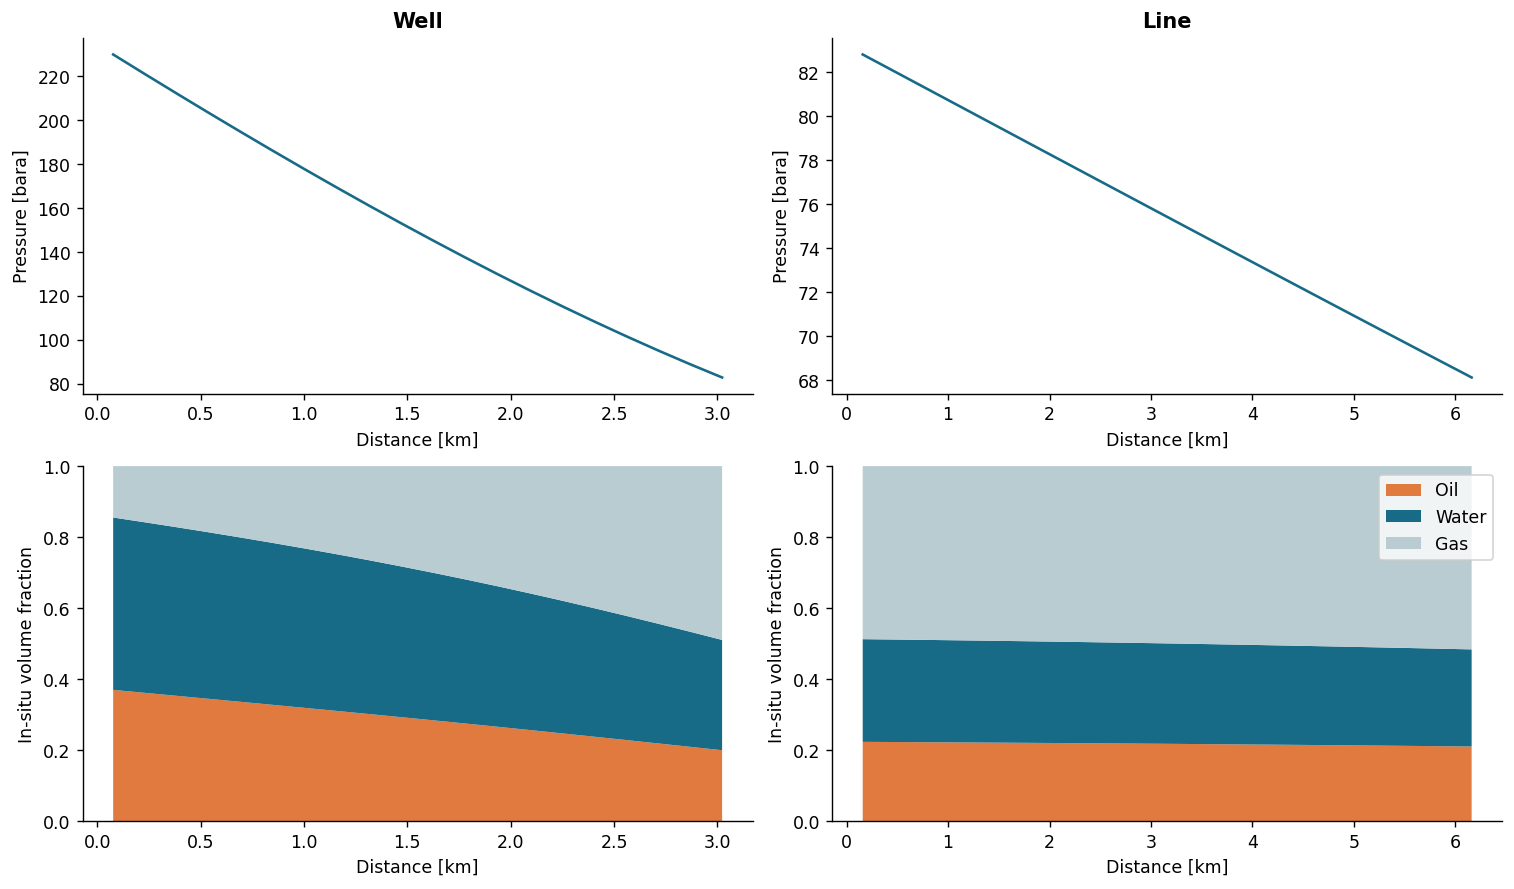

,sections_per_segment,arrival_bara,arrival_c
0,20,68.1162,56.5921
1,40,68.7033,55.9679


Mesh sensitivity is reported explicitly; two meshes do not prove mesh independence.


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for column, label in enumerate(["well", "line"]):
    profile = wet_transport[label + "_profile"]
    x = profile.distance_m / 1000
    axes[0, column].plot(x, profile.pressure_bara, color=COLORS[0])
    axes[0, column].set(
        title=label.capitalize(), ylabel="Pressure [bara]", xlabel="Distance [km]"
    )
    axes[1, column].stackplot(
        x,
        profile.oil_holdup,
        profile.water_holdup,
        1 - profile.liquid_holdup,
        labels=["Oil", "Water", "Gas"],
        colors=[COLORS[1], COLORS[0], "#B8CCD2"],
    )
    axes[1, column].set(xlabel="Distance [km]", ylabel="In-situ volume fraction", ylim=(0, 1))
axes[1, 1].legend(loc="upper right")
show_figure(fig, "06_three_phase_pressure_holdup")

fine_transport = transport(wet_oil, wet_gas, wet_water, 230.0, sections=40)
mesh_comparison = pd.DataFrame(
    {
        "sections_per_segment": [20, 40],
        "arrival_bara": [
            wet_transport["arrival"].getPressure("bara"),
            fine_transport["arrival"].getPressure("bara"),
        ],
        "arrival_c": [
            wet_transport["arrival"].getTemperature("C"),
            fine_transport["arrival"].getTemperature("C"),
        ],
    }
)
display(mesh_comparison.round(4))
print("Mesh sensitivity is reported explicitly; two meshes do not prove mesh independence.")


## 8. Flow assurance: steady operation and cooldown answer different questions

A warm arrival temperature does not prove safe shutdown or restart. We calculate a fresh-water
hydrate-equilibrium curve with NeqSim for the declared teaching gas composition and compare
it with the pipe temperature profile. The curve is an onset calculation, not a hydrate-growth
rate, plugging-time model, or proof that inhibition is sufficient.

The cooldown screen solves a lumped heat-capacity balance. It includes assumed steel-wall
heat capacity and fluid inventory, but ignores radial temperature gradients, local low points,
changing phase equilibrium and seabed thermal history. It is useful for understanding why
insulation and restart philosophy belong in a development decision.

$$T(t)=T_{sea}+(T_0-T_{sea})\exp(-UA t/C)$$

$T_0$ is initial temperature, $T_{sea}$ is seawater temperature, and $T(t)$ is the
lumped temperature, all in °C (temperature differences have the same value in K).
$U$ is W/(m² K), $A$ is exposed area in m², $C$ is combined fluid/steel heat capacity in J/K,
and time is seconds. Wax, asphaltene, scale, corrosion, emulsions, sand and severe slugging
need additional fluid, chemistry, surface and transient evidence.

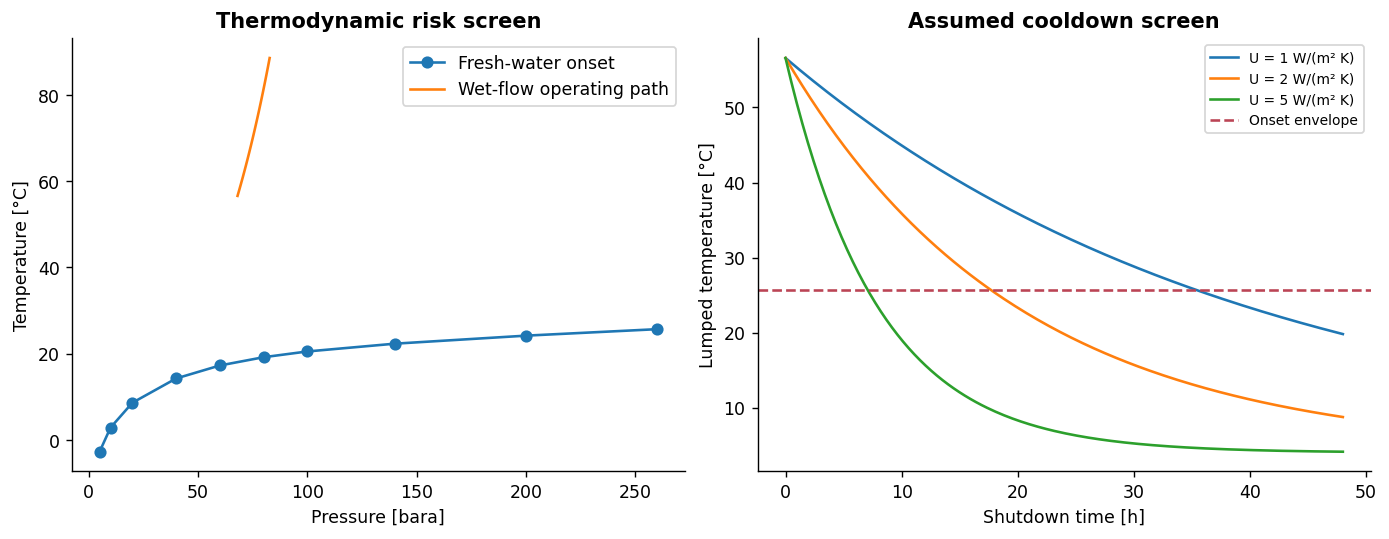

Operating-path pressures within hydrate interpolation domain: True
Minimum calculated temperature margin [K]: 38.548516098602185


In [14]:
hydrate_pressures = np.array([5.0, 10.0, 20.0, 40.0, 60.0, 80.0, 100.0, 140.0, 200.0, 260.0])
hydrate_temperatures = []
for pressure in hydrate_pressures:
    fluid = System(285.15, float(pressure))
    for component, fraction in GAS_Z.items():
        fluid.addComponent(component, float(fraction))
    fluid.addComponent("water", 1.0)
    fluid.setMixingRule(2)
    fluid.setMultiPhaseCheck(True)
    fluid.setHydrateCheck(True)
    Thermo(fluid).hydrateFormationTemperature()
    hydrate_temperatures.append(fluid.getTemperature("C"))
hydrate_temperatures = np.asarray(hydrate_temperatures)
assert np.all(np.isfinite(hydrate_temperatures))
assert np.all(np.diff(hydrate_temperatures) > 0)
profile = wet_transport["line_profile"]
hydrate_on_path = np.interp(profile.pressure_bara, hydrate_pressures, hydrate_temperatures)
pressure_domain_valid = bool(profile.pressure_bara.between(5, 260).all())
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(hydrate_pressures, hydrate_temperatures, "o-", label="Fresh-water onset")
axes[0].plot(profile.pressure_bara, profile.temperature_c, label="Wet-flow operating path")
axes[0].set(
    xlabel="Pressure [bara]", ylabel="Temperature [°C]", title="Thermodynamic risk screen"
)
axes[0].legend()
length = 6320.0
inner_diameter = 0.35
wall_thickness = 0.020
area = np.pi * (inner_diameter + 2 * wall_thickness) * length
steel_volume = (
    np.pi / 4 * ((inner_diameter + 2 * wall_thickness) ** 2 - inner_diameter**2) * length
)
fluid_volume = np.pi * inner_diameter**2 / 4 * length
heat_capacity = steel_volume * 7850 * 480 + fluid_volume * 400 * 2300
hours = np.linspace(0, 48, 200)
initial_temperature = float(profile.temperature_c.min())
for coefficient in [1.0, 2.0, 5.0]:
    temperature = 4 + (initial_temperature - 4) * np.exp(
        -coefficient * area * hours * 3600 / heat_capacity
    )
    axes[1].plot(hours, temperature, label=f"U = {coefficient:g} W/(m² K)")
axes[1].axhline(
    hydrate_temperatures.max(), color=COLORS[4], linestyle="--", label="Onset envelope"
)
axes[1].set(
    xlabel="Shutdown time [h]",
    ylabel="Lumped temperature [°C]",
    title="Assumed cooldown screen",
)
axes[1].legend(fontsize=8)
show_figure(fig, "07_hydrate_and_cooldown")
print("Operating-path pressures within hydrate interpolation domain:", pressure_domain_valid)
if pressure_domain_valid:
    print(
        "Minimum calculated temperature margin [K]:",
        float(np.min(profile.temperature_c - hydrate_on_path)),
    )
else:
    print("No path margin accepted: extend the equilibrium calculation pressure range.")


## 9. Tie-in to an existing installation

The host model contains an inlet choke, cooler, three-phase separator, and export-gas
compressor. Oil and water leave the separator as separate streams. The cooler target is
40 °C, separator pressure is 40 bara, export pressure is 120 bara, and compressor isentropic
efficiency is 0.78. These are teaching specifications.

Existing production consumes capacity. The relevant number for a new tie-in is **remaining
headroom**, not the nameplate capacity. We therefore calculate incremental gas mass, water
mass and power, then compare with alternative host-headroom scenarios. The simple model
does not include compressor maps, anti-surge recycle, dehydration, export specifications,
flare limits, water quality, slug-catcher dynamics or electrical-system transients.

A standalone process-load calculation may be performed at 45 bara to quantify host demand.
It is accepted as an integrated development point only when the well/subsea calculation
shows sufficient arrival pressure. Artificially raising the process inlet pressure does not
make an infeasible tieback feasible.

In [15]:
def facility(inlet, separator_pressure=40.0):
    process = ProcessSystem()
    inlet = inlet.clone("host inlet")
    choke = Valve("inlet choke", inlet)
    choke.setOutletPressure(float(separator_pressure), "bara")
    cooler = Cooler("inlet cooler", choke.getOutletStream())
    cooler.setOutTemperature(40.0, "C")
    separator = Separator("three-phase separator", cooler.getOutletStream())
    compressor = Compressor("export compressor", separator.getGasOutStream())
    compressor.setOutletPressure(120.0, "bara")
    compressor.setIsentropicEfficiency(0.78)
    for unit in [inlet, choke, cooler, separator, compressor]:
        process.add(unit)
    process.run()
    outputs = [
        separator.getGasOutStream(),
        separator.getOilOutStream(),
        separator.getWaterOutStream(),
    ]
    feed_mass = inlet.getFlowRate("kg/sec")
    output_mass = sum(stream.getFlowRate("kg/sec") for stream in outputs)
    residual = abs(output_mass - feed_mass) / max(feed_mass, 1e-12)
    assert residual < 1e-6, f"Facility mass residual: {residual}"
    component_residuals = []
    fluid = inlet.getFluid()
    for index in range(fluid.getNumberOfComponents()):
        source_moles = fluid.getComponent(index).getNumberOfmoles()
        out_moles = sum(s.getFluid().getComponent(index).getNumberOfmoles() for s in outputs)
        component_residuals.append(abs(out_moles - source_moles) / max(source_moles, 1e-12))
    assert max(component_residuals) < 1e-5
    return {
        "process": process,
        "separator": separator,
        "compressor": compressor,
        "power_MW": compressor.getPower("MW"),
        "gas_kg_s": outputs[0].getFlowRate("kg/sec"),
        "water_kg_s": outputs[2].getFlowRate("kg/sec"),
        "oil_kg_s": outputs[1].getFlowRate("kg/sec"),
        "mass_residual": residual,
        "component_residual": max(component_residuals),
    }


wet_facility = facility(wet_transport["arrival"])
display(
    pd.DataFrame(
        [{key: value for key, value in wet_facility.items() if isinstance(value, (float, int))}]
    ).round(6)
)
print(
    "Available choke pressure drop [bar]:", wet_transport["arrival"].getPressure("bara") - 40.0
)


,power_MW,gas_kg_s,water_kg_s,oil_kg_s,mass_residual,component_residual
0,0.222384,1.015665,2.98359,5.14982,0.0,0.0


Available choke pressure drop [bar]: 28.116226211588454


## 10. Define qualified simulator tools and evidence records

The coupled tool runs OPM, evaluates each well through the transport model at a selected
report, and evaluates the combined host load. For fast exploration we initially check the
last report only. Final candidates are checked at every stored report time. These checks
are still steady snapshots, not a continuous-time operability guarantee.

A forecast continues to be useful even if its tieback is rejected: it tells the optimizer
that a rate/BHP combination exceeds the assumed delivery envelope. Convergence failures
are recorded separately from physically insufficient arrival pressure.

,value
day,360.0
arrival_min_bara,60.087397
min_hydrate_margin_K,42.603862
hydraulic_status,converged
power_MW,0.761957
gas_kg_s,3.386462
water_kg_s,0.012045
oil_kg_s,45.107904
mass_residual,0.0
component_residual,0.0


Capacities deliberately bracket the base case for a teaching comparison.


,gas_kg_s,water_kg_s,power_MW
Ample host,6.772924,1.000000,1.523915
Gas/power constrained,2.878493,1.000000,0.647664
Water constrained,6.772924,0.007829,1.523915


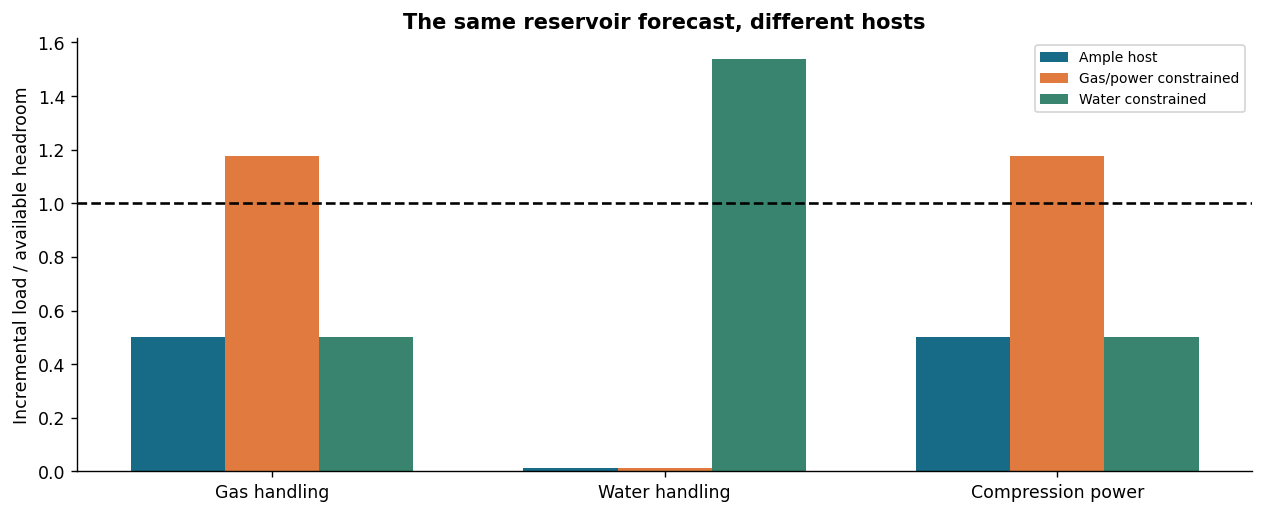

In [16]:
def assess_report(row, tubing=0.23, line_diameter=0.35):
    arrivals = []
    thermal_margins = []
    hydraulic_failure = None
    for well in ["B-2H", "D-1H"]:
        oil = float(row["WOPR:" + well])
        gas = float(row["WGPR:" + well])
        water = float(row["WWPR:" + well])
        if oil + gas + water <= 1e-9:
            continue
        try:
            result = transport(
                oil,
                gas,
                water,
                float(row["WBHP:" + well]),
                tubing=tubing,
                line_diameter=line_diameter,
            )
            arrivals.append(result["arrival"].getPressure("bara"))
            profile = result["line_profile"]
            if profile.pressure_bara.between(
                hydrate_pressures.min(), hydrate_pressures.max()
            ).all():
                onset = np.interp(
                    profile.pressure_bara, hydrate_pressures, hydrate_temperatures
                )
                thermal_margins.append(float(np.min(profile.temperature_c - onset)))
        except RuntimeError as error:
            hydraulic_failure = (
                f"{well}; oil={oil:.12g}, gas={gas:.12g}, water={water:.12g} Sm3/d; "
                f'BHP={float(row["WBHP:" + well]):.12g} bara; {error}'
            )
            break
    host_feed, _ = fluid_handoff(float(row.FOPR), float(row.FGPR), float(row.FWPR), 45.0)
    host = facility(host_feed)
    return {
        "day": float(row.day),
        "arrival_min_bara": min(arrivals) if arrivals else None,
        "min_hydrate_margin_K": (
            min(thermal_margins) if len(thermal_margins) == len(arrivals) and arrivals else None
        ),
        "hydraulic_status": "failed" if hydraulic_failure else "converged",
        "hydraulic_failure": hydraulic_failure,
        **{
            key: float(host[key])
            for key in [
                "power_MW",
                "gas_kg_s",
                "water_kg_s",
                "oil_kg_s",
                "mass_residual",
                "component_residual",
            ]
        },
    }


base_load = assess_report(base_forecast.iloc[-1])
display(pd.Series(base_load).drop("hydraulic_failure").to_frame("value"))
if base_load["hydraulic_failure"]:
    print(fill("Transport rejection: " + base_load["hydraulic_failure"], width=100))

# Headroom is scenario data, not a claim about the installed Norne host.
HEADROOM = {
    "Ample host": {
        "gas_kg_s": max(base_load["gas_kg_s"] * 2.0, 1.0),
        "water_kg_s": max(base_load["water_kg_s"] * 2.0, 1.0),
        "power_MW": max(base_load["power_MW"] * 2.0, 1.0),
    },
    "Gas/power constrained": {
        "gas_kg_s": max(base_load["gas_kg_s"] * 0.85, 0.01),
        "water_kg_s": max(base_load["water_kg_s"] * 2.0, 1.0),
        "power_MW": max(base_load["power_MW"] * 0.85, 0.01),
    },
    "Water constrained": {
        "gas_kg_s": max(base_load["gas_kg_s"] * 2.0, 1.0),
        "water_kg_s": max(base_load["water_kg_s"] * 0.65, 0.001),
        "power_MW": max(base_load["power_MW"] * 2.0, 1.0),
    },
}
print("Capacities deliberately bracket the base case for a teaching comparison.")
display(pd.DataFrame(HEADROOM).T)


def feasible(load, headroom):
    pressure = load["arrival_min_bara"]
    thermal_margin = load["min_hydrate_margin_K"]
    return bool(
        load["hydraulic_status"] == "converged"
        and pressure is not None
        and pressure >= 42.0
        and thermal_margin is not None
        and thermal_margin >= 3.0
        and all(load[key] <= headroom[key] for key in headroom)
    )


fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(3)
keys = ["gas_kg_s", "water_kg_s", "power_MW"]
for index, (scenario, capacities) in enumerate(HEADROOM.items()):
    values = [base_load[key] / capacities[key] for key in keys]
    ax.bar(x + (index - 1) * 0.24, values, width=0.24, label=scenario, color=COLORS[index])
ax.axhline(1, color="black", linestyle="--")
ax.set_xticks(x, ["Gas handling", "Water handling", "Compression power"])
ax.set(
    ylabel="Incremental load / available headroom",
    title="The same reservoir forecast, different hosts",
)
ax.legend(fontsize=8)
show_figure(fig, "08_host_bottleneck_comparison")


## 11. Train a surrogate on actual OPM results

The low-dimensional input vector contains two geological multipliers and two controls.
Each training row is a separate complete OPM run. The target is cumulative oil at day 360.
We never split a time series from one realization between training and test data.

A Gaussian process supplies a mean and predictive standard deviation. Its standard deviation
is model uncertainty conditional on the training data and kernel; it is not the geological
uncertainty distribution or a calibrated safety bound. We check performance on separately
sampled geological/control combinations and report the small validation sample size.
Kernel length scales can reach their configured bounds; the final audit displays those
fitting diagnostics. A weakly identified feature over one year is not evidence that it
is unimportant over field life.

The adaptive policy requests a new OPM calculation where a high predicted outcome and
uncertainty warrant exploration. This is a bounded numerical orchestrator, not an LLM making
engineering calculations. An LLM can explain logs or propose a typed request; the same tool
contract, budget and validation rules must still apply.

In [17]:
FEATURE_NAMES = ["k_mult", "pv_mult", "bhp", "injection"]
LOW = np.array([0.65, 0.92, 205.0, 2500.0])
HIGH = np.array([1.45, 1.08, 255.0, 6500.0])
N_INITIAL = 10
N_ADAPTIVE = 3
N_TEST = 4
EVIDENCE = [base_evidence]
TRAINING = []
GP_FIT_WARNINGS = []


def vector_parameters(vector):
    return {name: float(value) for name, value in zip(FEATURE_NAMES, vector)}


def reservoir_tool(vector, reason):
    frame, evidence = run_reservoir(vector_parameters(vector))
    EVIDENCE.append({**evidence, "reason": reason})
    return {
        "x": np.asarray(vector),
        "oil_sm3": float(frame.FOPT.iloc[-1]),
        "frame": frame,
        "id": evidence["id"],
    }


initial_design = qmc.scale(qmc.LatinHypercube(d=4, seed=391).random(N_INITIAL), LOW, HIGH)
started = time.perf_counter()
for index, vector in enumerate(initial_design):
    TRAINING.append(reservoir_tool(vector, f"initial design {index}"))
    print(f'Initial OPM run {index + 1}/{N_INITIAL}: {TRAINING[-1]["oil_sm3"]:.0f} Sm³')
initial_wall_s = time.perf_counter() - started


def fit_gp(records):
    features = np.array([record["x"] for record in records])
    target = np.array([record["oil_sm3"] for record in records]) / 1e6
    scaler = StandardScaler().fit(features)
    kernel = ConstantKernel(1.0, (0.01, 100)) * Matern(
        length_scale=np.ones(4),
        length_scale_bounds=(0.05, 20),
        nu=2.5,
    ) + WhiteKernel(1e-6, noise_level_bounds="fixed")
    model = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=7291)
    import warnings

    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        model.fit(scaler.transform(features), target)
    GP_FIT_WARNINGS.extend(str(item.message) for item in caught)
    return model, scaler


fixed_model, fixed_scaler = fit_gp(TRAINING)
proposal_pool = qmc.scale(qmc.LatinHypercube(d=4, seed=923).random(400), LOW, HIGH)
fixed_mean, fixed_std = fixed_model.predict(
    fixed_scaler.transform(proposal_pool), return_std=True
)
fixed_proposal = proposal_pool[np.argmax(fixed_mean)].copy()
acquisition_log = []
for iteration in range(N_ADAPTIVE):
    model, scaler = fit_gp(TRAINING)
    mean, std = model.predict(scaler.transform(proposal_pool), return_std=True)
    acquisition = mean + 1.5 * std
    chosen = int(np.argmax(acquisition))
    candidate = proposal_pool[chosen].copy()
    record = reservoir_tool(candidate, f"adaptive upper-confidence selection {iteration}")
    TRAINING.append(record)
    acquisition_log.append(
        {
            "iteration": iteration + 1,
            "predicted_million_sm3": mean[chosen],
            "std_million_sm3": std[chosen],
            "actual_million_sm3": record["oil_sm3"] / 1e6,
        }
    )
    proposal_pool = np.delete(proposal_pool, chosen, axis=0)
model, scaler = fit_gp(TRAINING)
display(pd.DataFrame(acquisition_log).round(4))


Initial OPM run 1/10: 3326643 Sm³
Initial OPM run 2/10: 2955870 Sm³
Initial OPM run 3/10: 2638596 Sm³
Initial OPM run 4/10: 3739000 Sm³


Initial OPM run 5/10: 2496704 Sm³
Initial OPM run 6/10: 2215515 Sm³
Initial OPM run 7/10: 1122172 Sm³
Initial OPM run 8/10: 1850531 Sm³
Initial OPM run 9/10: 1674956 Sm³
Initial OPM run 10/10: 2959501 Sm³


,iteration,predicted_million_sm3,std_million_sm3,actual_million_sm3
0,1,4.0098,0.1134,4.1256
1,2,4.0664,0.0545,4.1559
2,3,4.0827,0.0293,4.0841


,workflow,training_OPM_runs,test_MAE_million_sm3,test_R2
0,Fixed GP,10,0.0618,0.9916
1,Adaptive GP,13,0.0579,0.9905


Adaptive nominal 95% interval empirical coverage: 100% on 4 cases.
Four cases demonstrate the check; they do not establish a calibrated 95% guarantee.


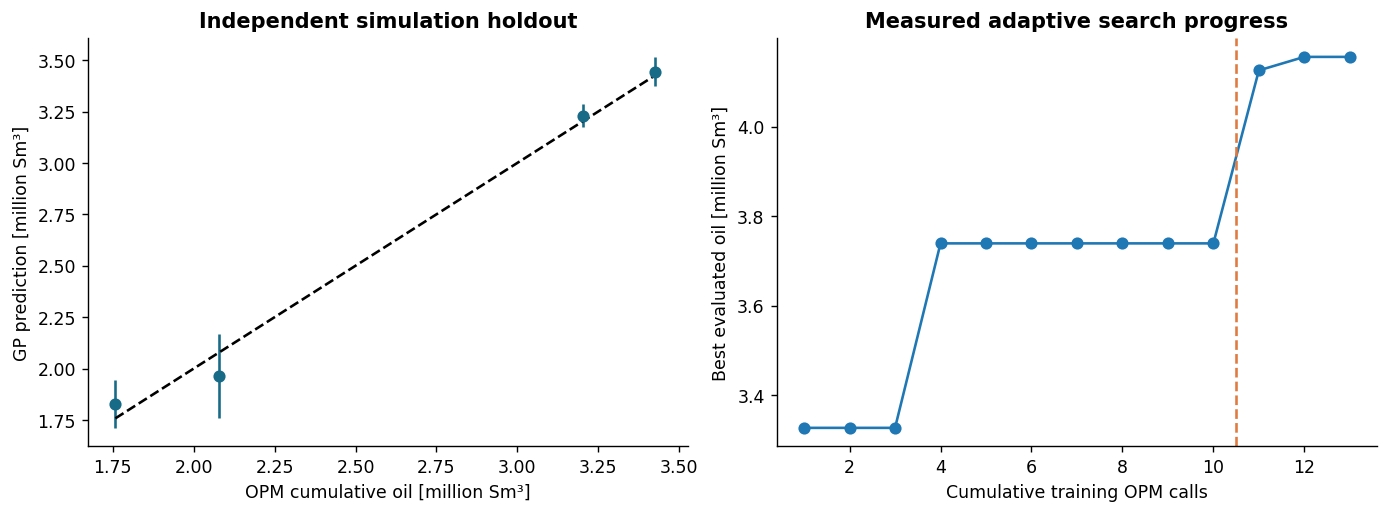

In [18]:
test_design = qmc.scale(qmc.LatinHypercube(d=4, seed=822).random(N_TEST), LOW, HIGH)
TEST = [reservoir_tool(vector, "held-out validation") for vector in test_design]
truth = np.array([record["oil_sm3"] for record in TEST]) / 1e6
prediction, uncertainty = model.predict(scaler.transform(test_design), return_std=True)
fixed_prediction = fixed_model.predict(fixed_scaler.transform(test_design))
coverage = np.mean(np.abs(truth - prediction) <= 1.96 * uncertainty)
metrics = pd.DataFrame(
    {
        "workflow": ["Fixed GP", "Adaptive GP"],
        "training_OPM_runs": [N_INITIAL, N_INITIAL + N_ADAPTIVE],
        "test_MAE_million_sm3": [
            mean_absolute_error(truth, fixed_prediction),
            mean_absolute_error(truth, prediction),
        ],
        "test_R2": [r2_score(truth, fixed_prediction), r2_score(truth, prediction)],
    }
)
display(metrics.round(4))
print(f"Adaptive nominal 95% interval empirical coverage: {coverage:.0%} on {N_TEST} cases.")
print("Four cases demonstrate the check; they do not establish a calibrated 95% guarantee.")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].errorbar(truth, prediction, yerr=1.96 * uncertainty, fmt="o", color=COLORS[0])
bounds = [min(truth.min(), prediction.min()), max(truth.max(), prediction.max())]
axes[0].plot(bounds, bounds, "k--")
axes[0].set(
    xlabel="OPM cumulative oil [million Sm³]",
    ylabel="GP prediction [million Sm³]",
    title="Independent simulation holdout",
)
values = np.array([record["oil_sm3"] for record in TRAINING]) / 1e6
axes[1].plot(np.arange(1, len(values) + 1), np.maximum.accumulate(values), "o-")
axes[1].axvline(N_INITIAL + 0.5, color=COLORS[1], linestyle="--")
axes[1].set(
    xlabel="Cumulative training OPM calls",
    ylabel="Best evaluated oil [million Sm³]",
    title="Measured adaptive search progress",
)
show_figure(fig, "09_surrogate_validation_and_search")


## 12. Optimize controls; do not optimize the geology

Permeability and pore volume are uncertain states, not control knobs. For decision comparison,
every operating policy is evaluated against the **same three geological realizations**.
Only BHP and injection rate vary between policies. The three equally weighted states are a
small teaching ensemble, not a calibrated posterior and not enough to support tail-risk claims.

We compare four declared policies. The fixed and adaptive surrogates rank this same finite
set by mean cumulative oil. Direct OPM calls then verify all four policies, allowing a fair
ranking-error comparison. This deliberately spends extra verification calls: it does not
claim a speedup for the whole notebook. Larger applications would verify a smaller shortlist
and add new simulations near uncertain constraint boundaries.

$$\max_u\;\frac{1}{N}\sum_r N_p(u,r)\quad\text{subject to }g_j(u,r)\le0$$

$u$ contains BHP and injection controls, $r$ indexes the $N$ geological realizations, and $g_j$
represents pressure and host-headroom constraints. Every policy uses identical realization
weights. Reservoir, surrogate, transport-model and commercial uncertainty remain distinct.

In [19]:
POLICIES = {
    "Low drawdown": {"bhp": 255.0, "injection": 6000.0},
    "Balanced": {"bhp": 230.0, "injection": 4500.0},
    "High drawdown": {"bhp": 205.0, "injection": 4500.0},
    "High support": {"bhp": 225.0, "injection": 6500.0},
}
GEOLOGY = [
    {"k_mult": 0.75, "pv_mult": 0.96},
    {"k_mult": 1.00, "pv_mult": 1.00},
    {"k_mult": 1.35, "pv_mult": 1.04},
]
policy_records = []
policy_forecasts = {}
for policy, controls in POLICIES.items():
    for realization, geology in enumerate(GEOLOGY):
        parameters = {**controls, **geology}
        vector = np.array([parameters[key] for key in FEATURE_NAMES])
        forecast, evidence = run_reservoir(parameters)
        EVIDENCE.append({**evidence, "reason": f"policy verification {policy}/{realization}"})
        policy_forecasts[(policy, realization)] = forecast
        load = assess_report(forecast.iloc[-1])
        policy_records.append(
            {
                "policy": policy,
                "realization": realization,
                "oil_million_sm3": forecast.FOPT.iloc[-1] / 1e6,
                "fixed_prediction": fixed_model.predict(fixed_scaler.transform([vector]))[0],
                "adaptive_prediction": model.predict(scaler.transform([vector]))[0],
                **load,
            }
        )
        print(policy, realization, "OPM verified; hydraulic status:", load["hydraulic_status"])
policy_table = pd.DataFrame(policy_records)
ranking = (
    policy_table.groupby("policy")[
        [
            "oil_million_sm3",
            "fixed_prediction",
            "adaptive_prediction",
        ]
    ]
    .mean()
    .sort_values("oil_million_sm3", ascending=False)
)
display(ranking.round(4))
print("Direct finite-set reservoir-only winner:", ranking.index[0])
print("Fixed-surrogate proposal:", ranking.fixed_prediction.idxmax())
print("Adaptive-surrogate proposal:", ranking.adaptive_prediction.idxmax())

# A deliberately limited end-report view makes the effect of host headroom visible.
# It is compared with the complete report-time qualification in the next cell.
snapshot_rows = []
for scenario, capacities in HEADROOM.items():
    for policy in POLICIES:
        rows = policy_table[policy_table.policy == policy]
        accepted = all(feasible(row, capacities) for row in rows.to_dict("records"))
        snapshot_rows.append(
            {"host": scenario, "policy": policy, "day_360_only_pass": accepted}
        )
snapshot_screen = pd.DataFrame(snapshot_rows)
display(snapshot_screen.pivot(index="policy", columns="host", values="day_360_only_pass"))
print("This table screens day 360 only; it does not qualify the operating policy.")


Low drawdown 0 OPM verified; hydraulic status: converged


Low drawdown 1 OPM verified; hydraulic status: converged


Low drawdown 2 OPM verified; hydraulic status: converged


Balanced 0 OPM verified; hydraulic status: converged


Balanced 1 OPM verified; hydraulic status: converged


...

High support 2 OPM verified; hydraulic status: converged


,oil_million_sm3,fixed_prediction,adaptive_prediction
policy,,,
High drawdown,3.8442,3.8200,3.8631
High support,2.7669,2.6936,2.7116
Balanced,2.5023,2.4729,2.4725
Low drawdown,1.1493,1.2045,1.1747


Direct finite-set reservoir-only winner: High drawdown
Fixed-surrogate proposal: High drawdown
Adaptive-surrogate proposal: High drawdown


host,Ample host,Gas/power constrained,Water constrained
policy,,,
Balanced,True,False,False
High drawdown,False,False,False
High support,True,False,False
Low drawdown,True,True,True


This table screens day 360 only; it does not qualify the operating policy.


### Capacity feedback changes the feasible set

An end-report screen is useful for teaching but cannot qualify an operating policy. The
next tool checks all nonzero stored report times for each policy/realization before making
the final comparisons. The flow-assurance screen requires a 3 K margin above the calculated
fresh-water hydrate-onset curve along each line; out-of-domain results are rejected. This
margin is a teaching criterion, not a field-qualified inhibition or restart requirement. It calculates host loads from actual OPM rates, while the well and
subsea model checks whether the imposed BHP can supply the receiving pressure.

The BHP already controls the reservoir calculation. Rejecting an infeasible rate/BHP pair
and selecting a newly simulated higher-BHP policy is a consistent outer feedback loop.
Simply clipping an OPM rate after the run would miss pressure, saturation and recovery feedback.

For a shared manifold, per-well backpressures and commingling must be solved together. Here
each producer has a separate assumed line to the common-pressure host; no shared-flowline
network is implied. Static mass balances do not establish a transient network solution.

In [20]:
report_checks = []
for (policy, realization), forecast in policy_forecasts.items():
    for _, row in forecast.iterrows():
        if row.day <= 0 or row.FOPR + row.FGPR + row.FWPR <= 1e-9:
            continue
        check = assess_report(row)
        report_checks.append({"policy": policy, "realization": realization, **check})
checks = pd.DataFrame(report_checks)
checks.to_csv(OUT / "coupled_report_checks.csv", index=False)
failures = checks.loc[checks.hydraulic_status != "converged", "hydraulic_failure"]
print("Rejected transport snapshots:", len(failures), "of", len(checks))
for message in failures.head(3):
    print(fill(message, width=100))
comparison_rows = []
for scenario, capacities in HEADROOM.items():
    for policy in POLICIES:
        rows = checks[checks.policy == policy]
        accepted = [feasible(row, capacities) for row in rows.to_dict("records")]
        pressure_fail = rows.arrival_min_bara.isna() | (rows.arrival_min_bara < 42)
        reasons = []
        if (rows.hydraulic_status != "converged").any():
            reasons.append("transport numerical validation")
        if pressure_fail.any():
            reasons.append("arrival pressure")
        if rows.min_hydrate_margin_K.isna().any() or rows.min_hydrate_margin_K.min() < 3.0:
            reasons.append("thermal hydrate screen")
        for key in capacities:
            if rows[key].max() > capacities[key]:
                reasons.append(key)
        oil_values = policy_table.loc[policy_table.policy == policy, "oil_million_sm3"]
        comparison_rows.append(
            {
                "host": scenario,
                "policy": policy,
                "all_report_checks_pass": all(accepted),
                "mean_oil_million_sm3": oil_values.mean(),
                "Q10_oil_million_sm3": oil_values.quantile(0.1),
                "Q90_oil_million_sm3": oil_values.quantile(0.9),
                "limiting_checks": ", ".join(reasons) or "none in tested envelope",
            }
        )
comparison = pd.DataFrame(comparison_rows)
display(
    comparison.rename(
        columns={
            "all_report_checks_pass": "All reports pass",
            "mean_oil_million_sm3": "Mean oil [million Sm3]",
            "Q10_oil_million_sm3": "Q10 oil [million Sm3]",
            "Q90_oil_million_sm3": "Q90 oil [million Sm3]",
            "limiting_checks": "Limiting checks",
        }
    )
    .style.format(precision=4)
    .set_properties(
        **{"white-space": "normal", "max-width": "190px"},
    )
)
for scenario in HEADROOM:
    accepted = comparison[(comparison.host == scenario) & comparison.all_report_checks_pass]
    if accepted.empty:
        print(
            scenario + ": no accepted policy in the tested set; further design work required."
        )
    else:
        winner = accepted.sort_values("mean_oil_million_sm3", ascending=False).iloc[0]
        print(f"{scenario}: best tested feasible policy = {winner.policy}")
        feasible_names = accepted.policy.tolist()
        print(
            "  Fixed-GP proposal in the qualified feasible set:",
            ranking.loc[feasible_names].fixed_prediction.idxmax(),
        )
        print(
            "  Adaptive-GP proposal in the qualified feasible set:",
            ranking.loc[feasible_names].adaptive_prediction.idxmax(),
        )


Rejected transport snapshots: 12 of 182
B-2H; oil=15069.4462891, gas=1630701.625, water=7.13818359375 Sm3/d; BHP=205 bara; well: phase mass
closure failed; expected=166.113217788 kg/s, profile=[162.639371191, 166.113217788] kg/s
B-2H; oil=13474.0429688, gas=1455368.625, water=6.57006454468 Sm3/d; BHP=205 bara; flowline and
riser: PRESSURE_FLOOR_LIMIT, {'pressure_momentum': 5.697048855112786e-06, 'pressure_update':
3.449626118417922e-05, 'liquid_holdup': 7.653283682997059e-06, 'liquid_split': 0.0, 'thermodynamic':
0.0, 'pressure_drop': 0.0}
B-2H; oil=11775.6992188, gas=1259899.25, water=6.21393346786 Sm3/d; BHP=205 bara; flowline and
riser: PRESSURE_FLOOR_LIMIT, {'pressure_momentum': 2.4015059592328315e-07, 'pressure_update':
1.6521953400463614e-06, 'liquid_holdup': 4.405773269017255e-06, 'liquid_split': 0.0,
'thermodynamic': 0.0, 'pressure_drop': 0.0}


,host,policy,All reports pass,Mean oil [million Sm3],Q10 oil [million Sm3],Q90 oil [million Sm3],Limiting checks
0,Ample host,Low drawdown,True,1.1493,1.0815,1.2168,none in tested envelope
1,Ample host,Balanced,False,2.5023,2.3440,2.6602,"arrival pressure, gas_kg_s, power_MW"
2,Ample host,High drawdown,False,3.8442,3.6002,4.0878,"transport numerical validation, arrival pressure, thermal hydrate screen, gas_kg_s, power_MW"
3,Ample host,High support,False,2.7669,2.5947,2.9396,"arrival pressure, gas_kg_s, power_MW"
4,Gas/power constrained,Low drawdown,False,1.1493,1.0815,1.2168,"gas_kg_s, power_MW"
5,Gas/power constrained,Balanced,False,2.5023,2.3440,2.6602,"arrival pressure, gas_kg_s, power_MW"
6,Gas/power constrained,High drawdown,False,3.8442,3.6002,4.0878,"transport numerical validation, arrival pressure, thermal hydrate screen, gas_kg_s, power_MW"
7,Gas/power constrained,High support,False,2.7669,2.5947,2.9396,"arrival pressure, gas_kg_s, power_MW"
8,Water constrained,Low drawdown,True,1.1493,1.0815,1.2168,none in tested envelope
9,Water constrained,Balanced,False,2.5023,2.3440,2.6602,"arrival pressure, gas_kg_s, water_kg_s, power_MW"


Ample host: best tested feasible policy = Low drawdown
  Fixed-GP proposal in the qualified feasible set: Low drawdown
  Adaptive-GP proposal in the qualified feasible set: Low drawdown
Gas/power constrained: no accepted policy in the tested set; further design work required.
Water constrained: best tested feasible policy = Low drawdown
  Fixed-GP proposal in the qualified feasible set: Low drawdown
  Adaptive-GP proposal in the qualified feasible set: Low drawdown


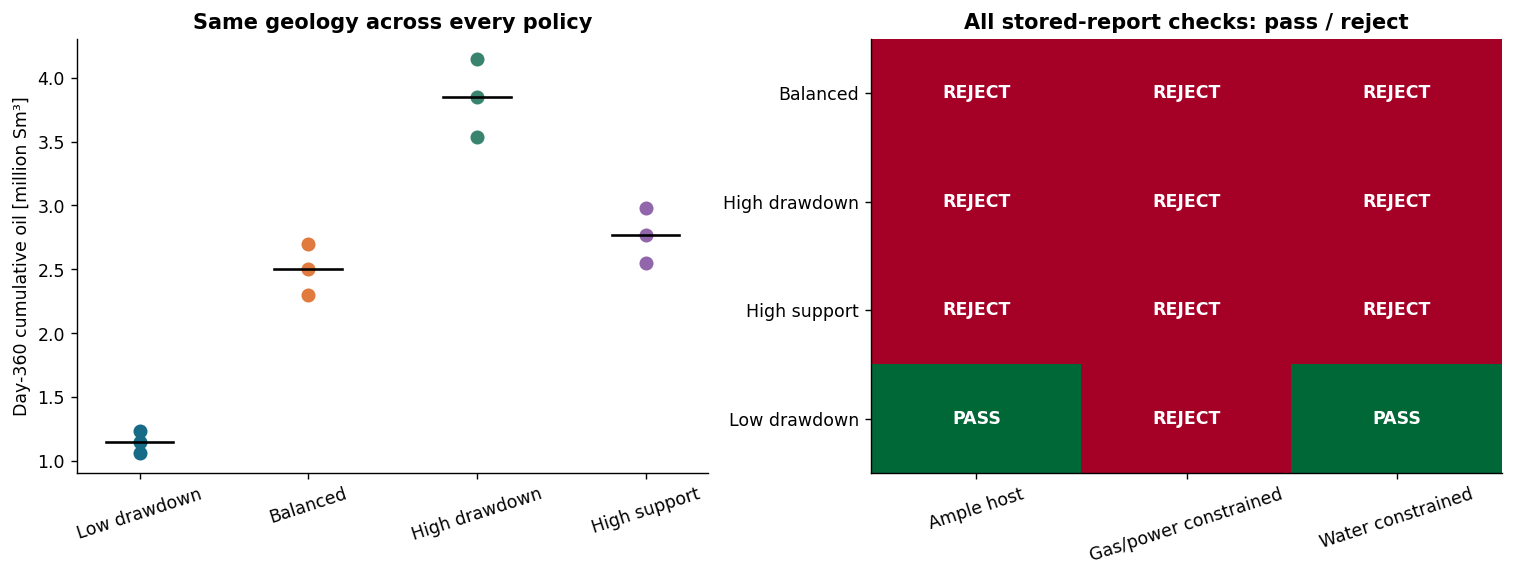

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for index, policy in enumerate(POLICIES):
    values = policy_table.loc[policy_table.policy == policy, "oil_million_sm3"].to_numpy()
    axes[0].scatter(np.full(3, index), values, color=COLORS[index], s=50)
    axes[0].plot([index - 0.2, index + 0.2], [values.mean()] * 2, color="black")
axes[0].set_xticks(range(4), list(POLICIES), rotation=18)
axes[0].set(
    ylabel="Day-360 cumulative oil [million Sm³]", title="Same geology across every policy"
)
matrix = comparison.pivot(index="policy", columns="host", values="all_report_checks_pass")
axes[1].imshow(matrix.to_numpy(dtype=int), cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
axes[1].set_xticks(range(len(matrix.columns)), matrix.columns, rotation=18)
axes[1].set_yticks(range(len(matrix.index)), matrix.index)
axes[1].set_title("All stored-report checks: pass / reject")
for i in range(len(matrix.index)):
    for j in range(len(matrix.columns)):
        axes[1].text(
            j,
            i,
            "PASS" if matrix.iloc[i, j] else "REJECT",
            ha="center",
            va="center",
            color="white",
            fontweight="bold",
        )
show_figure(fig, "10_integrated_decision_map")


## 13. When topsides is not the bottleneck

Host headroom only has value if another part of the chain can use it. The following
counterfactual holds the wet-flow fluid and BHP fixed while varying tubing and flowline
internal diameter over a deliberately broad envelope, including undersized tubing.
We compare delivery pressure against the receiving-pressure requirement. Increasing host power
capacity cannot repair inadequate well/subsea delivery pressure.

Conversely, a larger line can be economically unhelpful if the host is already limited by
water handling or compression. A complete development optimization includes capital cost,
installation constraints, availability, operating cost and schedule. We show a break-even
calculation using declared hypothetical values; these are not equipment quotations.

,tubing_m,line_m,arrival_bara,delivery_pass,status
0,0.06,0.25,NaN,False,rejected
1,0.06,0.35,NaN,False,rejected
2,0.06,0.45,NaN,False,rejected
3,0.08,0.25,41.609,False,converged
4,0.08,0.35,42.194,True,converged
5,0.08,0.45,42.537,True,converged
6,0.12,0.25,67.087,True,converged
7,0.12,0.35,67.124,True,converged
8,0.12,0.45,66.992,True,converged


Rejected design diagnostic: well: PRESSURE_FLOOR_LIMIT, {'pressure_momentum':
1.3335376158438007e-07, 'pressure_update': 5.970314452867137e-06, 'liquid_holdup':
5.598096347453341e-06, 'liquid_split': 1.8648627670078688e-06, 'thermodynamic': 0.0,
'pressure_drop': 0.0}


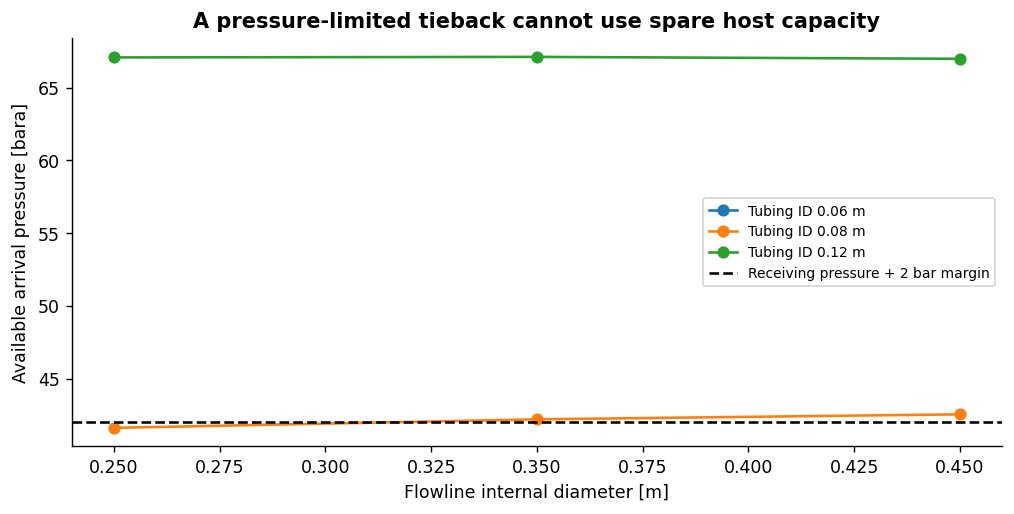

Illustrative one-year break-even incremental oil: 47,143 Sm³.
Netback = 350 currency units/Sm³; upgrade = 15 million; discount rate = 10%.
Use integrated policy differences; do not value unavailable reservoir potential.


In [22]:
design_rows = []
for tubing in [0.06, 0.08, 0.12]:
    for diameter in [0.25, 0.35, 0.45]:
        try:
            trial = transport(
                wet_oil, wet_gas, wet_water, 230, tubing=tubing, line_diameter=diameter
            )
            arrival = trial["arrival"].getPressure("bara")
            design_rows.append(
                {
                    "tubing_m": tubing,
                    "line_m": diameter,
                    "arrival_bara": arrival,
                    "delivery_pass": arrival >= 42,
                    "status": "converged",
                    "reason": "",
                }
            )
        except RuntimeError as error:
            design_rows.append(
                {
                    "tubing_m": tubing,
                    "line_m": diameter,
                    "arrival_bara": np.nan,
                    "delivery_pass": False,
                    "status": "rejected",
                    "reason": str(error),
                }
            )
design_table = pd.DataFrame(design_rows)
display(design_table.drop(columns=["reason"]).round(3))
for reason in design_table.loc[~design_table.delivery_pass, "reason"].unique():
    if reason:
        print(fill("Rejected design diagnostic: " + reason, width=100))
fig, ax = plt.subplots(figsize=(8, 4))
for tubing, rows in design_table.groupby("tubing_m"):
    ax.plot(rows.line_m, rows.arrival_bara, "o-", label=f"Tubing ID {tubing:.2f} m")
ax.axhline(42, color="black", linestyle="--", label="Receiving pressure + 2 bar margin")
ax.set(
    xlabel="Flowline internal diameter [m]",
    ylabel="Available arrival pressure [bara]",
    title="A pressure-limited tieback cannot use spare host capacity",
)
ax.legend(fontsize=8)
show_figure(fig, "11_tubing_flowline_tradeoff")

assumed_netback_per_sm3 = 350.0
assumed_upgrade_cost = 15e6
assumed_discount_rate = 0.10
break_even_extra_sm3 = (
    assumed_upgrade_cost * (1 + assumed_discount_rate) / assumed_netback_per_sm3
)
print(f"Illustrative one-year break-even incremental oil: {break_even_extra_sm3:,.0f} Sm³.")
print("Netback = 350 currency units/Sm³; upgrade = 15 million; discount rate = 10%.")
print("Use integrated policy differences; do not value unavailable reservoir potential.")


## 14. Recoverable volumes, uncertainty and what more data is worth

The ensemble describes a one-year forecast under declared controls. Mathematical Q10 is
the low 10th percentile and Q90 is the high 90th percentile. In petroleum exceedance
notation the low recoverable-volume outcome is often called P90 and the high outcome P10.
We use Q notation throughout to avoid ambiguity. Three realizations are insufficient for
stable tails, and the notebook does not assign a reserves/resource category.

A seismic survey may reduce structural uncertainty; a well test may reduce productivity
uncertainty; PVT measurements may reduce flash and transport uncertainty; a capacity test
may reduce host uncertainty. The valuable measurement depends on which uncertain input
can change the integrated decision. Reducing uncertainty in a nonbinding quantity may not
change the preferred action.

A practical value-of-information study would repeat the decision problem under possible
measurement outcomes and subtract the measurement cost. Ranking raw feature importance
is not equivalent to value of information or causal attribution.

In [23]:
uncertainty_register = pd.DataFrame(
    [
        [
            "Reservoir state",
            "k and porosity multipliers",
            "Three common states in policy comparison",
            "Spatial ensembles, history conditioning, relative permeability, faults",
        ],
        [
            "Data interpretation",
            "Synthetic impedance experiment",
            "Spatial holdout MAE",
            "Observed seismic/log likelihood and calibrated posterior",
        ],
        [
            "Fluid model",
            "Black-oil masses to surrogate composition",
            "Exact total mass handoff",
            "Compositional PVT match, brine chemistry, phase-volume validation",
        ],
        [
            "Transport",
            "TwoFluidPipe and assumed trajectory",
            "Residuals, phase closure, two meshes",
            "Field/experimental validation, transient slugging and thermal qualification",
        ],
        [
            "Host",
            "Three specified headroom scenarios",
            "Native mass and component balances",
            "Maps, equipment capacities, water quality, trips, power and export limits",
        ],
        [
            "ML",
            "GP kernel and limited design",
            "Four independent validation cases",
            "Larger holdout, interval calibration, OOD detection and constraint learning",
        ],
    ],
    columns=["uncertainty", "representation", "evidence here", "next evidence"],
)
display(
    uncertainty_register.style.set_properties(
        **{"white-space": "normal", "max-width": "230px"},
    )
)


,uncertainty,representation,evidence here,next evidence
0,Reservoir state,k and porosity multipliers,Three common states in policy comparison,"Spatial ensembles, history conditioning, relative permeability, faults"
1,Data interpretation,Synthetic impedance experiment,Spatial holdout MAE,Observed seismic/log likelihood and calibrated posterior
2,Fluid model,Black-oil masses to surrogate composition,Exact total mass handoff,"Compositional PVT match, brine chemistry, phase-volume validation"
3,Transport,TwoFluidPipe and assumed trajectory,"Residuals, phase closure, two meshes","Field/experimental validation, transient slugging and thermal qualification"
4,Host,Three specified headroom scenarios,Native mass and component balances,"Maps, equipment capacities, water quality, trips, power and export limits"
5,ML,GP kernel and limited design,Four independent validation cases,"Larger holdout, interval calibration, OOD detection and constraint learning"


## 15. Traceable automation and interfaces for a larger agent workflow

The executed adaptive loop has a defined proposal policy, simulator tools, numerical checks,
cache identities and a fixed computational budget. It is an elementary agentic workflow.
It does not require an LLM service or send data to one.

A future LLM coordinator can call the same typed tools for case setup, model inspection,
simulation, validation, surrogate fitting and decision comparison. It should explain why
new information is needed and stop when the budget is exhausted. It should not edit source
observations, choose favorable realizations, hide convergence failures, loosen constraints,
or claim a rejected result is a validated optimum.

Reinforcement learning is a possible later extension for sequential control. This notebook
uses surrogate-assisted search because it is easier to audit with a small simulation budget.
RL would additionally need a validated transition model, observation model, reward design,
constraint enforcement, safe exploration and an independent comparison with conventional
control. A GP or a rule-based orchestrator is not a physics-informed neural network or RL.

In [24]:
unique_runs = {record["id"]: record for record in EVIDENCE}
run_table = pd.DataFrame(
    [
        {
            "id": record["id"],
            "elapsed_s": record["elapsed_s"],
            "exit_code": record["exit_code"],
            "reason": record.get("reason", "base"),
        }
        for record in unique_runs.values()
    ]
)
start = time.perf_counter()
model.predict(scaler.transform(proposal_pool))
inference_s = time.perf_counter() - start
print("Unique actual OPM runs:", len(unique_runs))
print("Distinct GP fitting diagnostics:", len(set(GP_FIT_WARNINGS)))
for message in sorted(set(GP_FIT_WARNINGS)):
    print(fill(message, width=100))
(OUT / "gp_fit_diagnostics.json").write_text(json.dumps(GP_FIT_WARNINGS, indent=2))
print("Recorded OPM solve time [s]:", run_table.elapsed_s.sum())
print(f"GP prediction for {len(proposal_pool)} candidates [s]: {inference_s:.6f}")
print("Inference speed excludes training, sampling, NeqSim, and final simulator verification.")
display(run_table)

pd.DataFrame(OUTLET_REFRESH_AUDIT).to_csv(OUT / "outlet_refresh_audit.csv", index=False)
comparison.to_csv(OUT / "development_decisions.csv", index=False)
policy_table.to_csv(OUT / "policy_realizations.csv", index=False)
run_table.to_csv(OUT / "simulation_costs.csv", index=False)
ledger = {
    "model_version": MODEL_VERSION,
    "provenance": provenance,
    "data_commit": DATA_COMMIT,
    "policies": POLICIES,
    "geological_states": GEOLOGY,
    "headroom": HEADROOM,
    "runs": list(unique_runs.values()),
    "figures": FIGURES,
    "limitations": [
        "Hypothetical forecast, well, subsea and host specifications",
        "Black-oil mass mapping is not a matched compositional PVT model",
        "Steady checks at report times; no transient operability qualification",
        "Small teaching ensemble; no calibrated tail or reserves claims",
    ],
}
(OUT / "engineering_ledger.json").write_text(json.dumps(ledger, indent=2))
print(
    fill("Reusable outputs: " + ", ".join(path.name for path in OUT.glob("*.csv")), width=100)
)


Unique actual OPM runs: 29
Distinct GP fitting diagnostics: 2
The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified
upper bound 20.0. Increasing the bound and calling fit again may find a better value.
The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified
upper bound 20.0. Increasing the bound and calling fit again may find a better value.
Recorded OPM solve time [s]: 247.81427827399966
GP prediction for 397 candidates [s]: 0.000833
Inference speed excludes training, sampling, NeqSim, and final simulator verification.


,id,elapsed_s,exit_code,reason
0,05cd6ed3882dec37,8.681443,0,policy verification Balanced/1
1,54bd76e26078bbf5,9.034570,0,initial design 0
2,8c3d59825230ceda,8.281639,0,initial design 1
3,b2d46b95e6d39494,7.782439,0,initial design 2
4,ec170586184d88bc,8.831960,0,initial design 3
5,c10eee34c26bc168,8.432418,0,initial design 4
6,07183e2af9344397,8.985194,0,initial design 5
7,6ef47efcd1cc5208,7.983498,0,initial design 6
8,162cee23433f4892,8.383104,0,initial design 7
9,d34780e93a535920,8.032500,0,initial design 8


Reusable outputs: coupled_report_checks.csv, development_decisions.csv, policy_realizations.csv,
outlet_refresh_audit.csv, simulation_costs.csv


## 16. What the demonstration establishes

Read the calculated decision table rather than assuming that an upgrade is always valuable.
If the reservoir-only winner fails delivery pressure, change the reservoir control or the
well/subsea design and rerun. If it passes delivery but fails host headroom, evaluate a
lower-load policy or a host modification. If all tested policies are rejected, the correct
result is an unresolved development problem, not a fabricated feasible optimum.

The essential lesson is that reservoir engineering, data science, flow assurance and
facilities engineering share a coupled decision. Their separate models become useful as an
integrated workflow only when pressure datums, mass/component accounting, time indices,
uncertainty, convergence and constraints travel with the data.

### Suggested classroom experiments

- Increase host gas/power headroom only. Does the preferred policy change, or does pressure bind?
- Increase tubing diameter while retaining host limits. Can the installation use the extra rate?
- Double the simulation design size and compare fixed versus adaptive holdout error.
- Add independent geological realizations. How stable are the preferred policy and quantiles?
- Replace the surrogate composition with a characterized and matched PVT fluid.
- Introduce a wet late-life reservoir forecast and qualified thermal/restart constraints.
- Replace the screening economics with a multi-year discounted model including availability.

### Sources and companion notebooks

- [OPM Flow manuals](https://opm-project.org/?page_id=955): deck keywords, black-oil equations,
  schedule controls, pressure datums and summary conventions.
- [Norne open reservoir data](https://github.com/OPM/opm-data/tree/eaa2261683a97027e057c2bc49612ad1c86390b3/norne):
  immutable data source with embedded licenses.
- [NeqSim TwoFluidPipe source](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/process/equipment/pipeline/TwoFluidPipe.java):
  implemented phase treatment, pressure, thermal and diagnostic interfaces.
- [NeqSim hydrate models](https://equinor.github.io/neqsim/thermo/hydrate_models.html): equilibrium scope.
- [Gaussian-process documentation](https://scikit-learn.org/stable/modules/gaussian_process.html):
  predictive mean, standard deviation and kernel assumptions.
- [FMU/Norne introduction](fmu_norne_subsurface_to_facilities_workflow.ipynb): portable precursor.
- [RMS → OPM Flow → ERT](rms_to_opm_flow_agent_ert.ipynb): reservoir workflow integration.
- [Example book](../examples_of_NeqSim_in_Colab.ipynb): thermodynamics, flow assurance and facilities.

**Validation boundary:** source integrity, native simulator completion, forecast sanity,
unit-labelled interfaces, phase-volume/flux closure, convergence diagnostics, process mass
and component balances, numerical sensitivity and independent ML holdout are demonstrated.
Field validation, design qualification and continuous-time constraint satisfaction are not.

In [25]:
validation = {
    "source_files_verified": len(manifest),
    "source_active_cells": int(active.sum()),
    "OPM_unique_successful_runs": len(unique_runs),
    "coupled_report_checks": len(checks),
    "hydraulic_convergence_failures_recorded": int(
        (checks.hydraulic_status != "converged").sum()
    ),
    "maximum_process_mass_residual": float(checks.mass_residual.max()),
    "maximum_process_component_residual": float(checks.component_residual.max()),
    "ML_holdout_cases": N_TEST,
    "retained_figures": len(FIGURES),
}
assert validation["maximum_process_mass_residual"] < 1e-6
assert validation["maximum_process_component_residual"] < 1e-5
print(json.dumps(validation, indent=2))
_ = (OUT / "validation.json").write_text(json.dumps(validation, indent=2))


{
  "source_files_verified": 64,
  "source_active_cells": 44927,
  "OPM_unique_successful_runs": 29,
  "coupled_report_checks": 182,
  "hydraulic_convergence_failures_recorded": 12,
  "maximum_process_mass_residual": 1.4344705707549295e-12,
  "maximum_process_component_residual": 1.6097599728730054e-12,
  "ML_holdout_cases": 4,
  "retained_figures": 11
}
